In [1]:
import time
notebook_start = time.perf_counter()

import  os, json, joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    matplotlib.ticker import AutoMinorLocator
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.ensemble import RandomForestRegressor
from    sklearn.metrics import mean_squared_error
from    sklearn.model_selection import learning_curve

OUTPUT_FOLDER = "RF_THICKNESS_OUTPUTS"
TEST_ROWS     = None
N_JOBS        = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
print(f"RF parallel jobs: {N_JOBS}")


In [2]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\ninterfacial_thickness statistics:")
print(df["interfacial_thickness"].describe())

Total samples: 19361

interfacial_thickness statistics:
count    19361.000000
mean         1.353666
std          0.682266
min          0.682573
25%          0.887208
50%          1.109909
75%          1.574425
max          5.659519
Name: interfacial_thickness, dtype: float64


In [3]:
target     = "interfacial_thickness"
SEED       = 655552
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


Feature correlations with interfacial_thickness:
temperature           0.849221
pressure              0.801291
z_hydrogen            0.079105
z_argon               0.027194
z_nitrogen            0.011509
z_carbon monoxide     0.002335
z_hydrogen sulfide    0.001279
z_methane            -0.000599
z_oxygen             -0.010977
z_carbon dioxide     -0.067627
Name: interfacial_thickness, dtype: float64


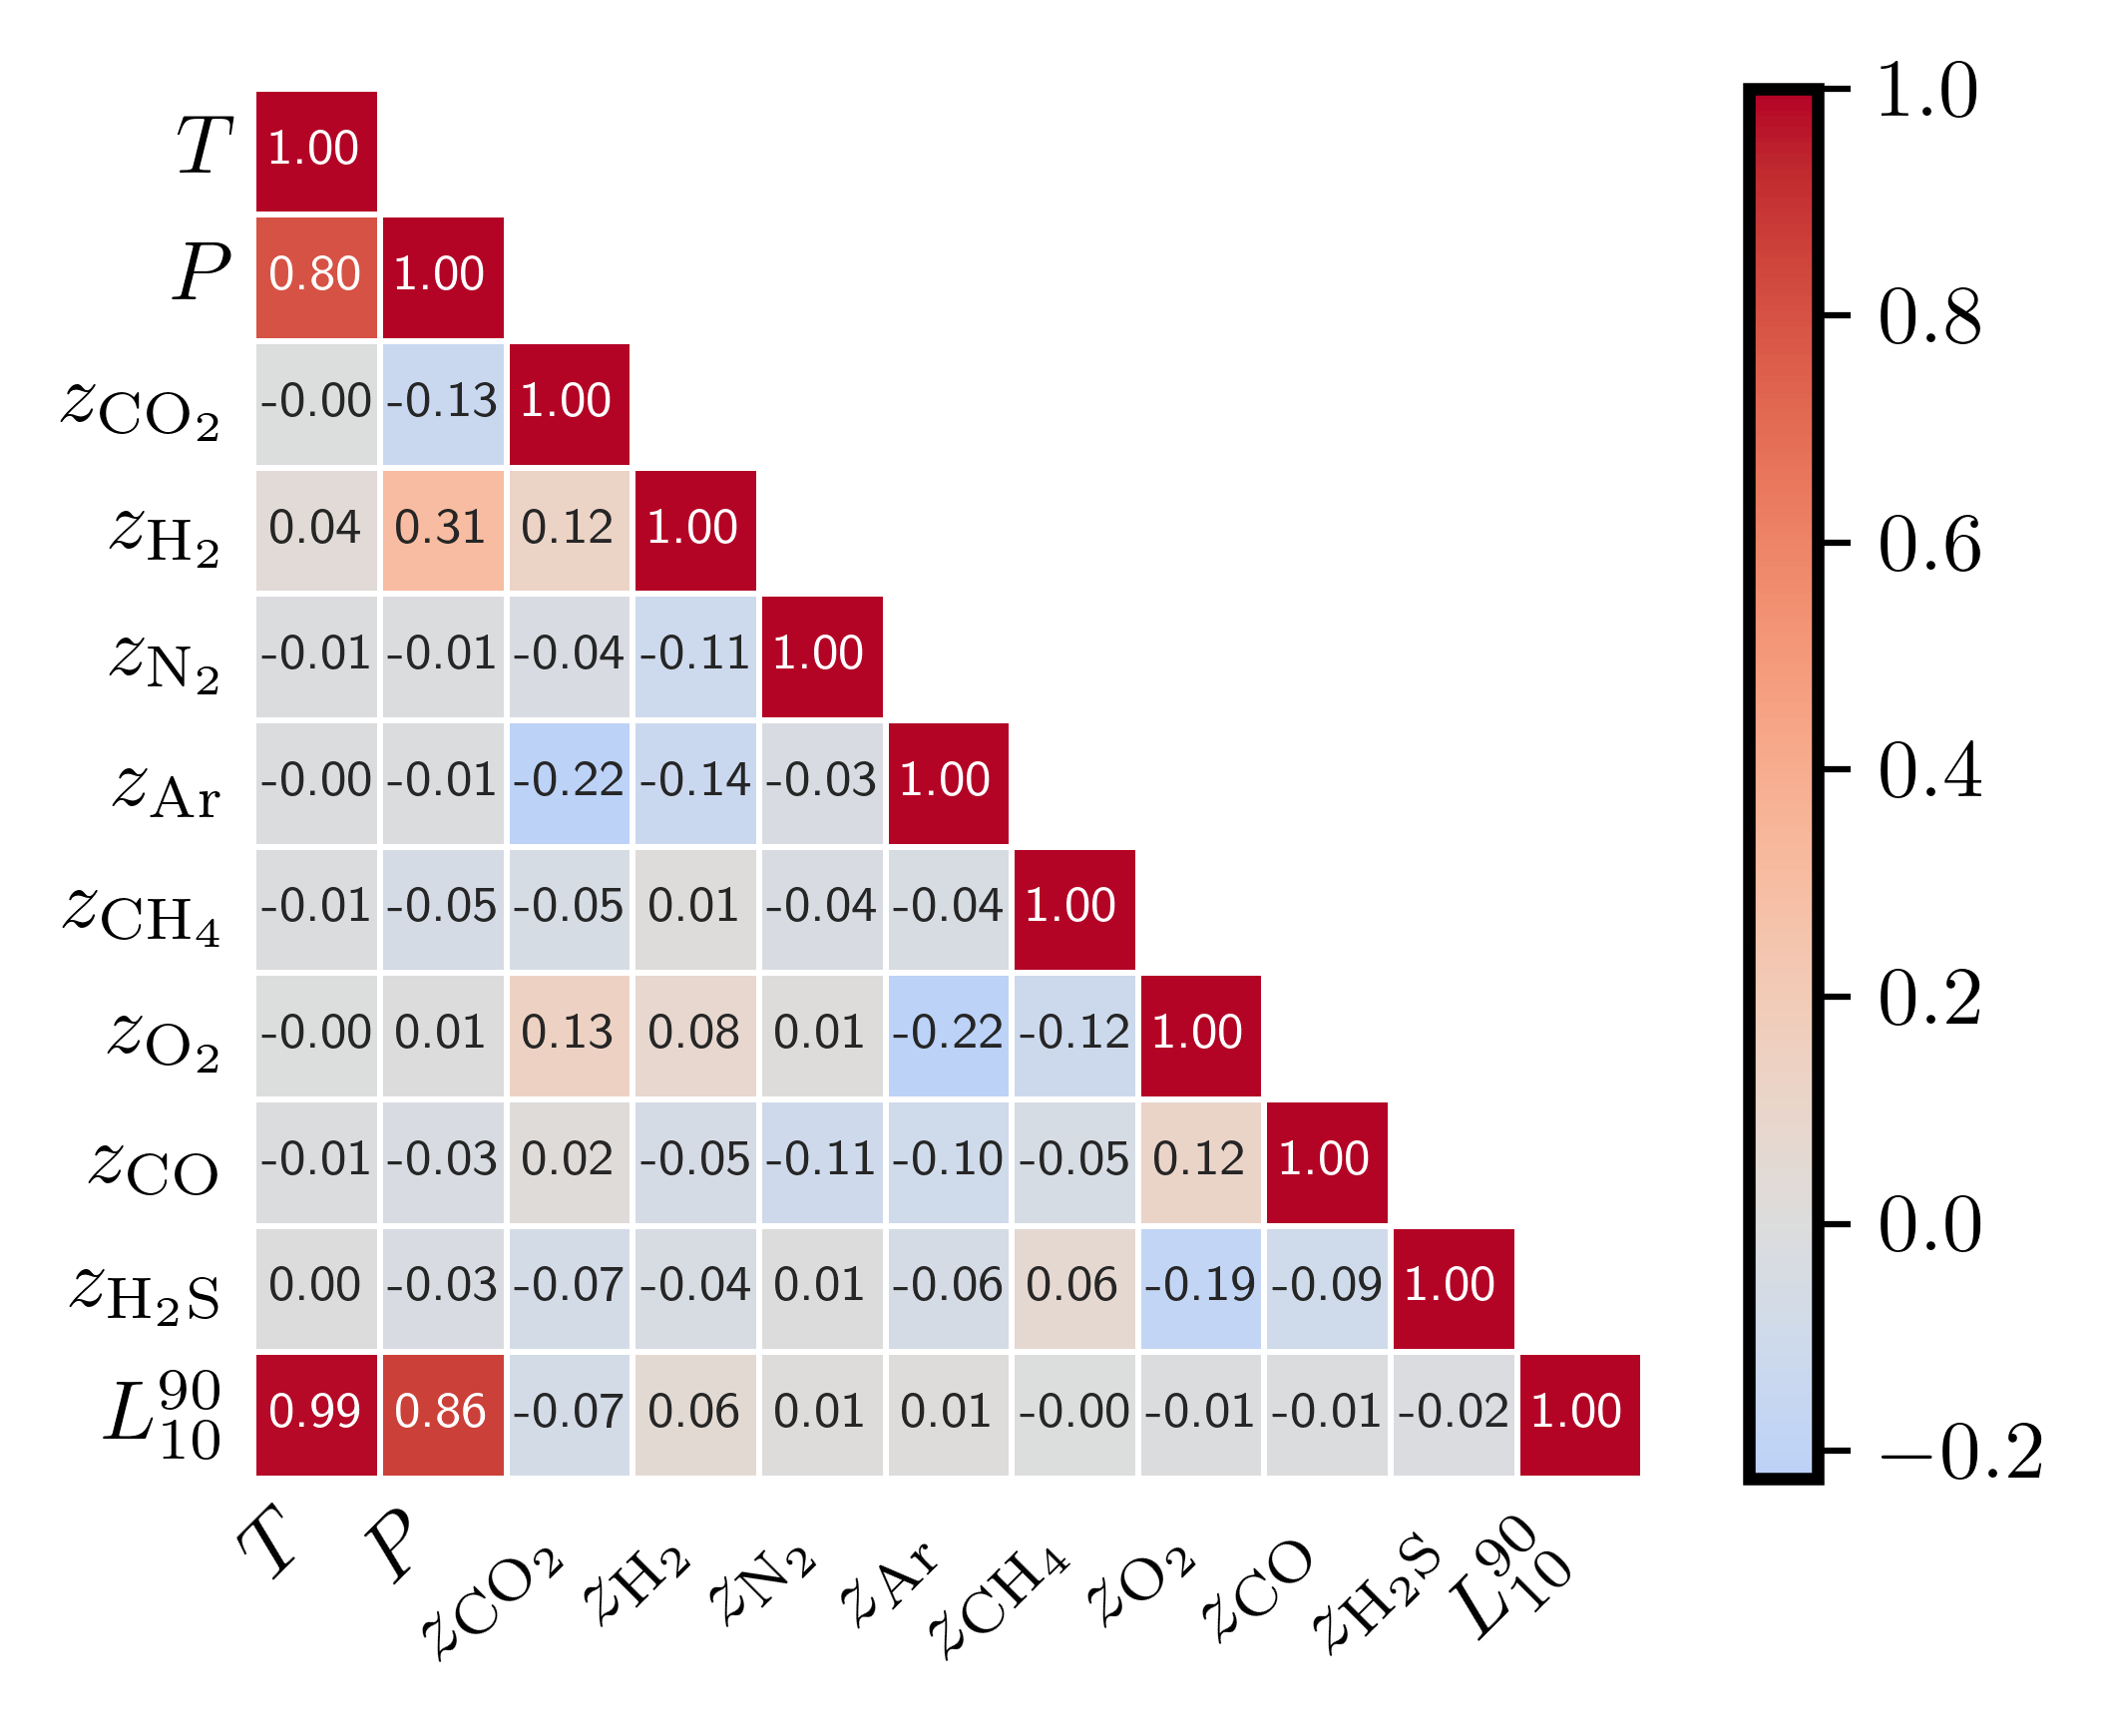

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [4]:
plot_correlation_heatmap(df, features, target, save_path="RF_interfacial_thickness_correlation", folder=OUTPUT_FOLDER)

In [5]:
# Train Random Forest model
Trees = 200

rf_model = RandomForestRegressor(
    n_estimators=Trees,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEED,
    oob_score=True,
    n_jobs=N_JOBS
)

rf_model.fit(X_train, y_train)
print(f"OOB R² Score: {rf_model.oob_score_:.6f}")

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)
y_val_pred   = rf_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="nm", y_val=y_val, y_val_pred=y_val_pred)

OOB R² Score: 0.999465
Model Performance for interfacial_thickness

Training Set:
  R²:   0.999927
  RMSE: 0.005845 nm
  MAE:  0.002611 nm

Test Set:
  R²:   0.999450
  RMSE: 0.016157 nm
  MAE:  0.006787 nm

Validation Set:
  R²:   0.999620
  RMSE: 0.013126 nm
  MAE:  0.006555 nm


In [6]:
# Save predictions for post-hoc outlier analysis (no retraining needed)
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: RF_THICKNESS_OUTPUTS/RF_interfacial_thickness_model.joblib


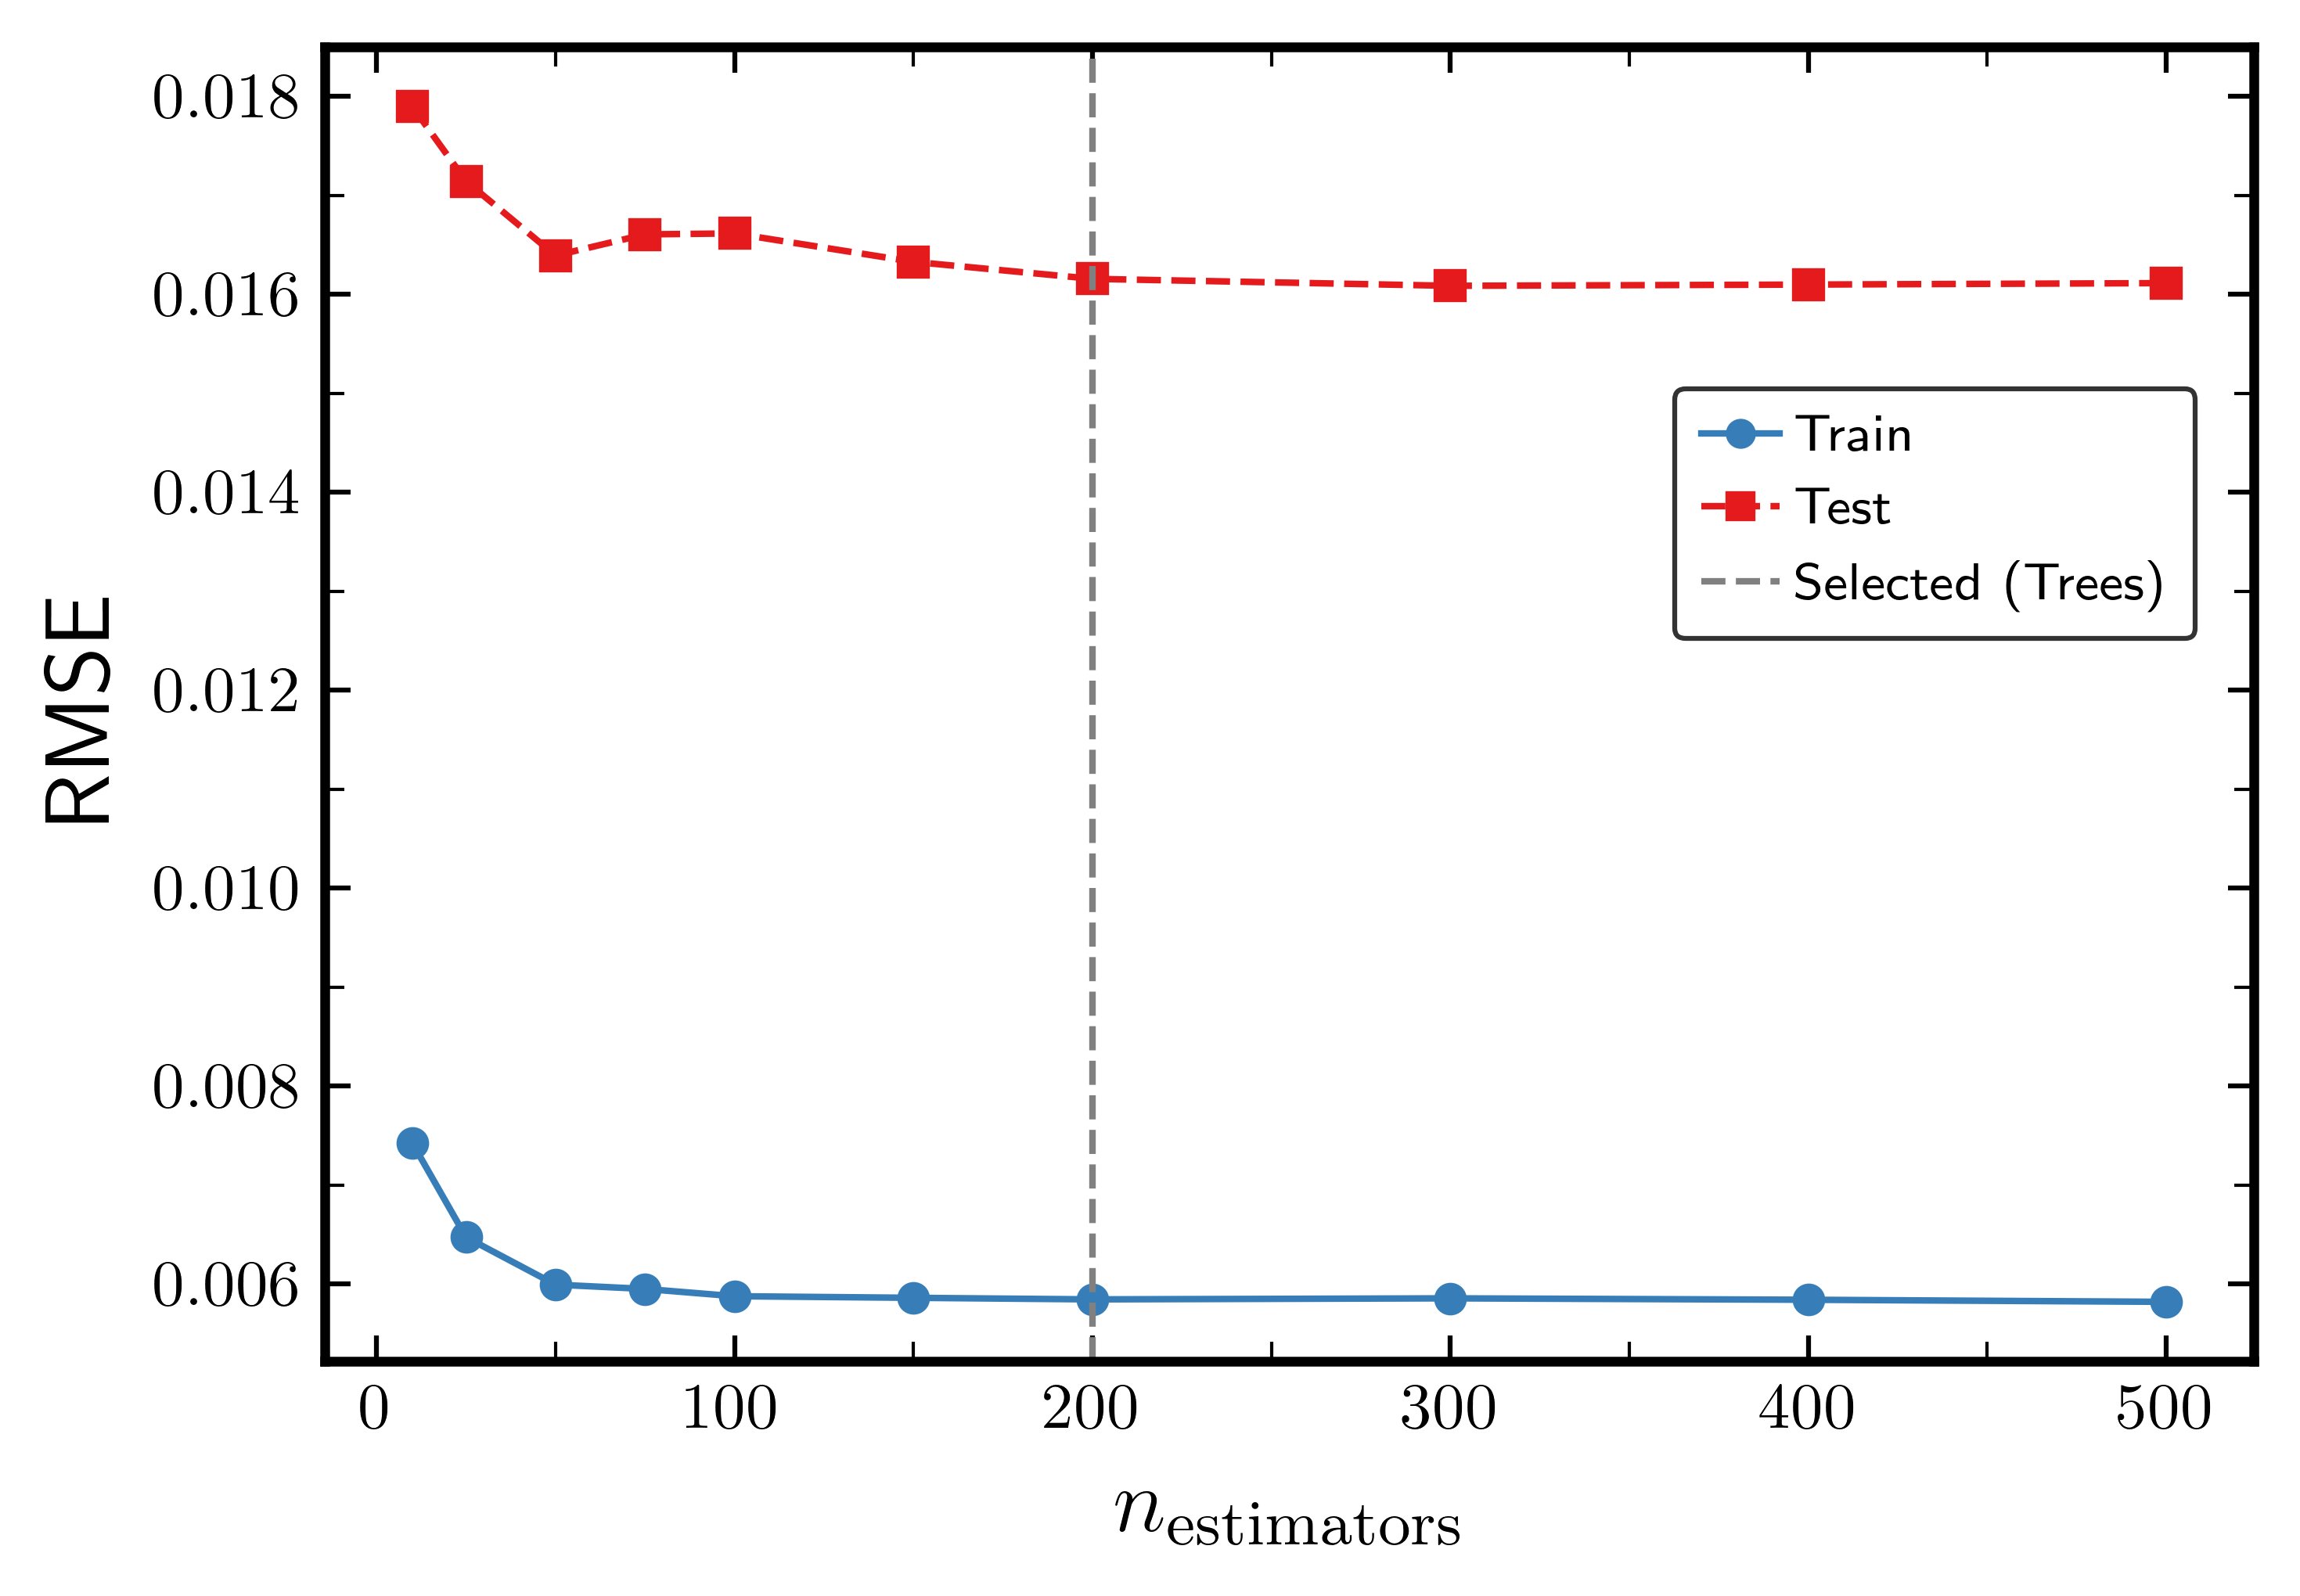

Saved: RF_interfacial_thickness_nestimators_convergence


In [7]:
# n_estimators convergence: RMSE vs number of trees
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.
checkpoints = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
train_rmse_conv = []
cv_rmse_conv    = []
test_rmse_conv  = []

for n in checkpoints:
    _conv_model = RandomForestRegressor(
        n_estimators=n, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
    )
    _conv_model.fit(X_train, y_train)
    train_rmse_conv.append(np.sqrt(mean_squared_error(y_train, _conv_model.predict(X_train))))
    test_rmse_conv.append( np.sqrt(mean_squared_error(y_test,  _conv_model.predict(X_test))))
    cv_rmse_conv.append(
        -cross_val_score(
            _conv_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(checkpoints, train_rmse_conv, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train')
ax.plot(checkpoints, cv_rmse_conv, marker='^', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[1], label='CV')
ax.plot(checkpoints, test_rmse_conv,  marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='Test')
ax.axvline(Trees, ls='--', color='gray', lw=ps.linewidth, label='Selected (Trees)')
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper right')
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_nestimators_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_nestimators_convergence")


In [ ]:
# max_depth convergence: RMSE vs tree depth
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.

depth_checkpoints = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_rmse_depth = []
cv_rmse_depth    = []
test_rmse_depth  = []

for depth in depth_checkpoints:
    _depth_model = RandomForestRegressor(
        n_estimators=Trees,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=N_JOBS,
    )
    _depth_model.fit(X_train, y_train)
    train_rmse_depth.append(np.sqrt(mean_squared_error(y_train, _depth_model.predict(X_train))))
    test_rmse_depth.append( np.sqrt(mean_squared_error(y_test,  _depth_model.predict(X_test))))
    cv_rmse_depth.append(
        -cross_val_score(
            _depth_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

depth_labels = ["None" if depth is None else str(depth) for depth in depth_checkpoints]
x_depth = np.arange(len(depth_labels))

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(x_depth, train_rmse_depth, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train')
ax.plot(x_depth, cv_rmse_depth, marker='^', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[1], label='CV')
ax.plot(x_depth, test_rmse_depth,  marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='Test')

selected_depth = "None" if rf_model.max_depth is None else str(rf_model.max_depth)
if selected_depth in depth_labels:
    ax.axvline(depth_labels.index(selected_depth), ls='--', color='gray', lw=ps.linewidth,
               label='Selected (max_depth)')

ax.set_xticks(x_depth)
ax.set_xticklabels(depth_labels)
ax.set_xlabel(r"$\mathrm{max\ depth}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper right')
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_max_depth_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_max_depth_convergence")


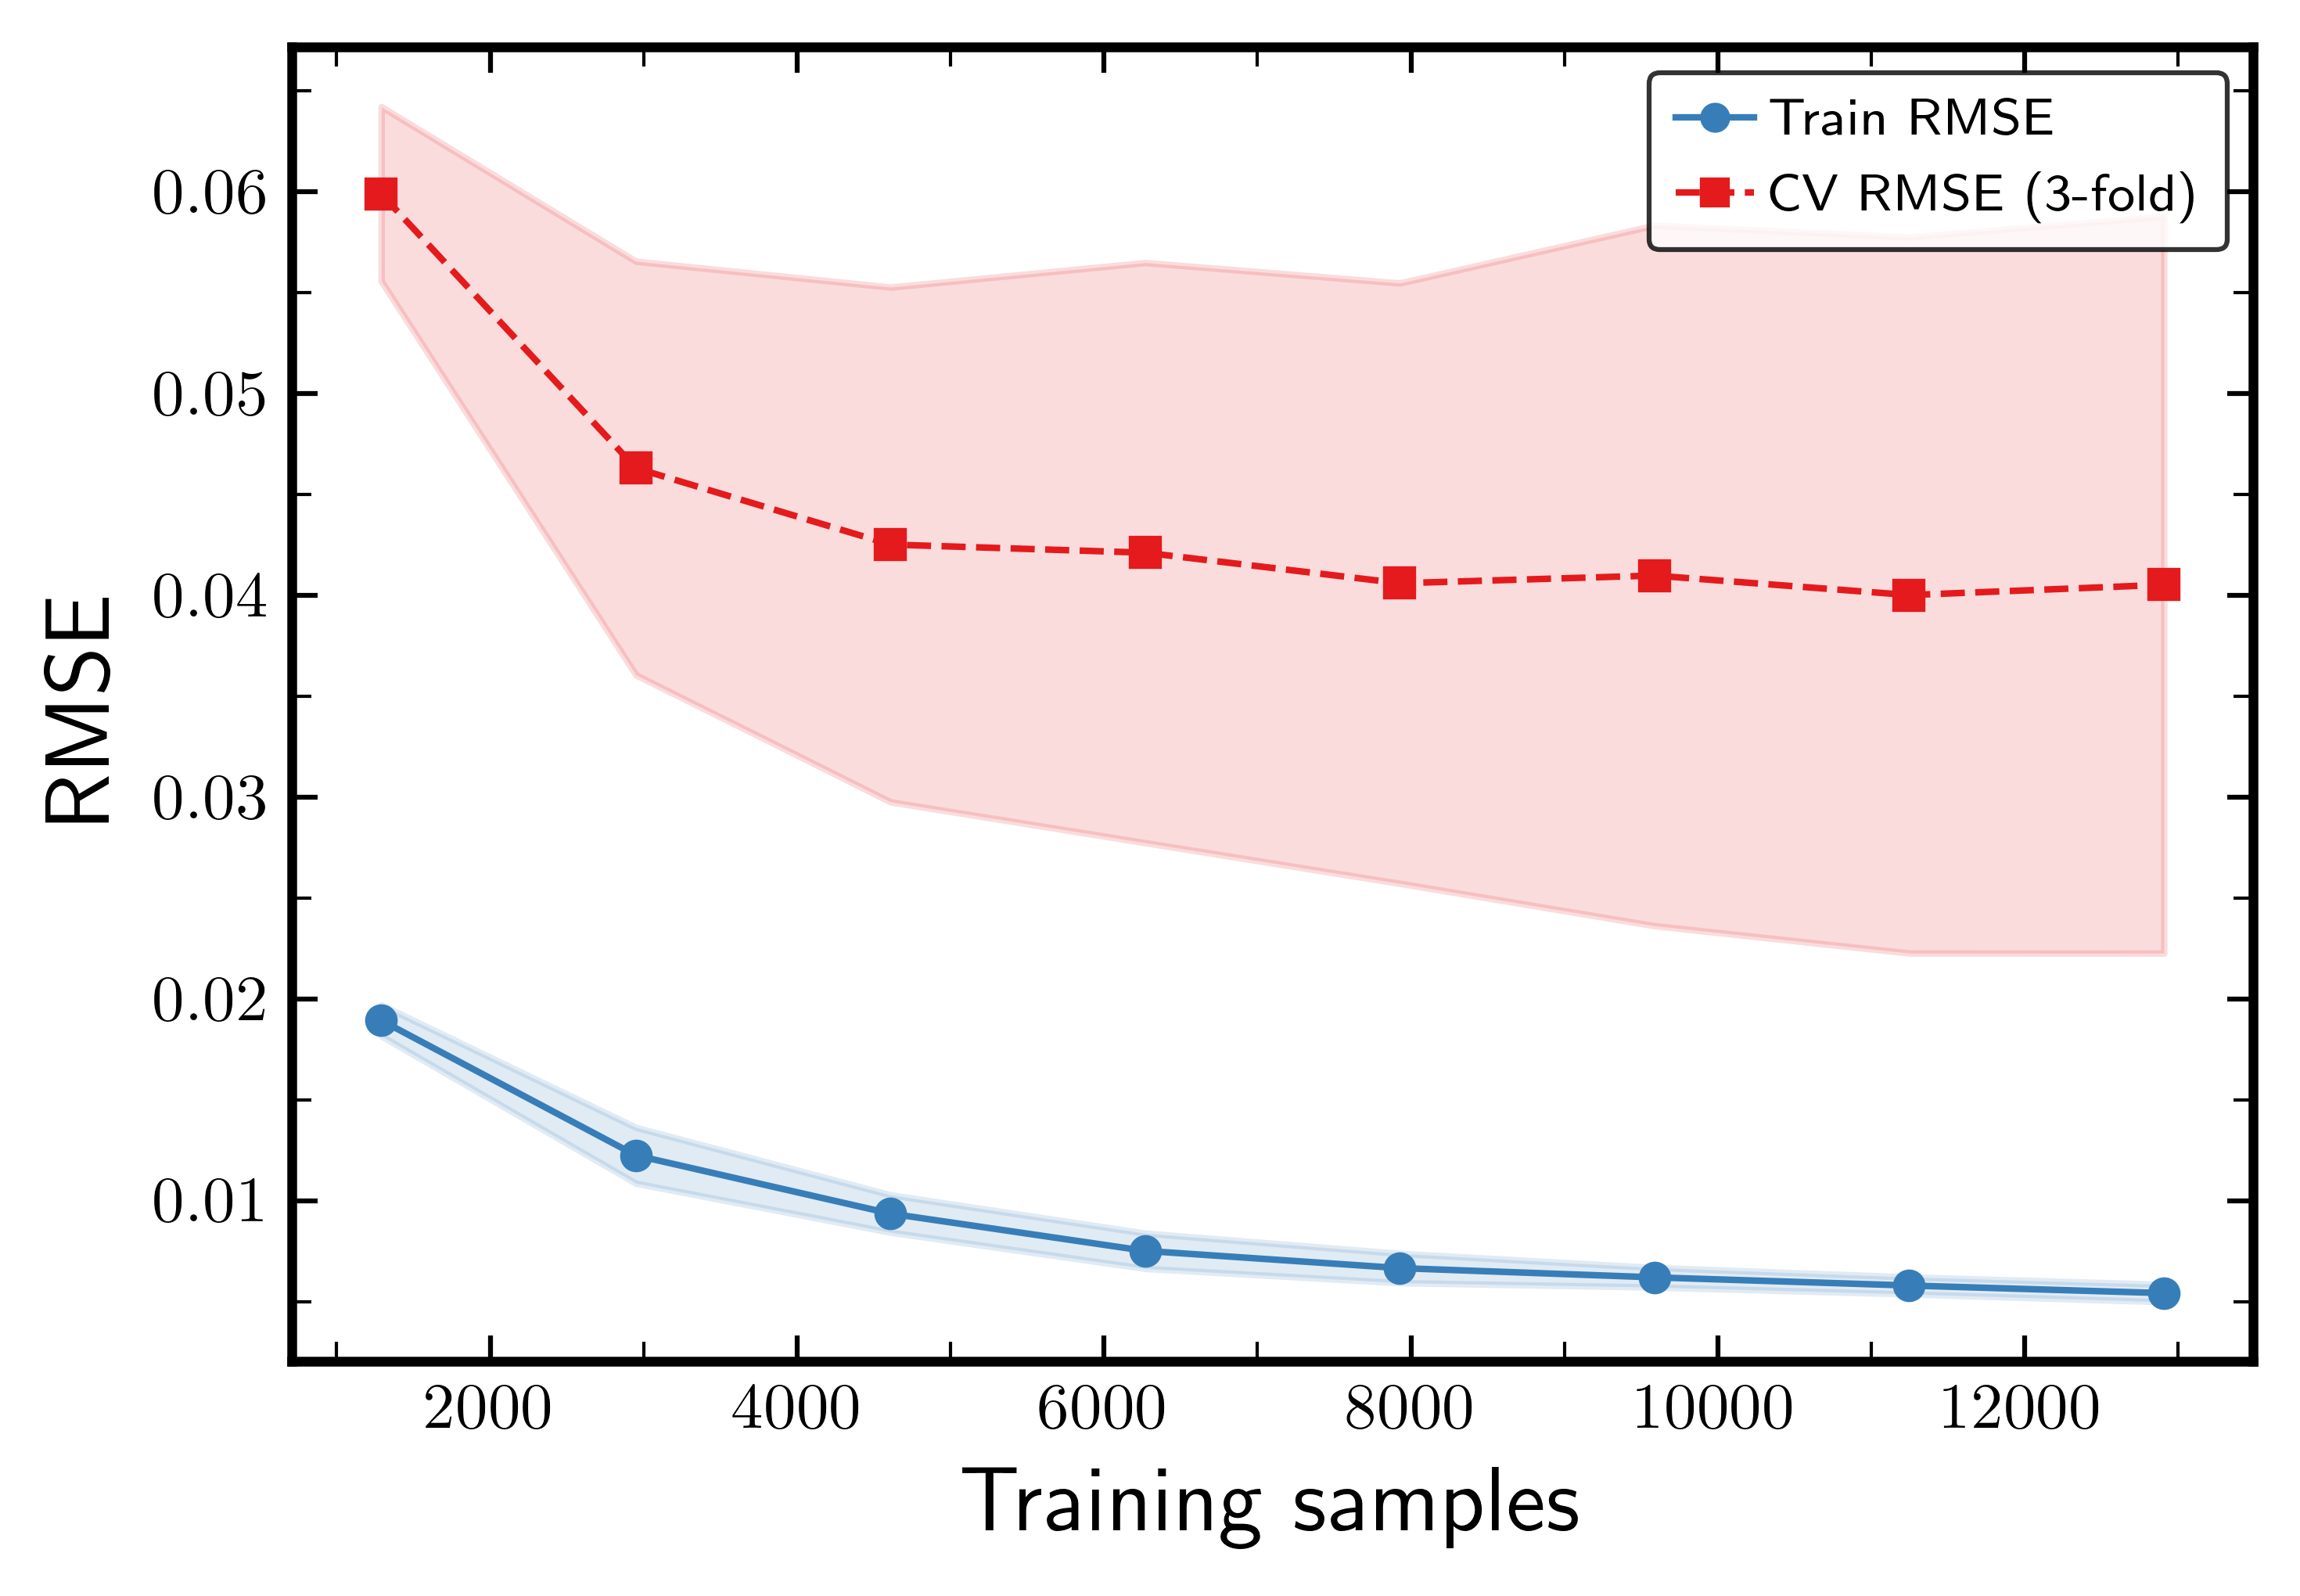

Saved: RF_interfacial_thickness_learning_curve


In [8]:
# Learning curve — evaluates whether more data would improve the model
# Uses n_estimators=100 for speed; 5-fold CV across 8 training-set fractions
lc_estimator = RandomForestRegressor(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
)

train_sizes, train_scores, val_scores = learning_curve(
    lc_estimator, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error',
    n_jobs=N_JOBS, shuffle=True, random_state=SEED
)

train_rmse_lc = -train_scores.mean(axis=1)
val_rmse_lc   = -val_scores.mean(axis=1)
train_std_lc  =  train_scores.std(axis=1)
val_std_lc    =  val_scores.std(axis=1)

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(train_sizes, train_rmse_lc, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train RMSE')
ax.fill_between(train_sizes, train_rmse_lc - train_std_lc, train_rmse_lc + train_std_lc,
                color=ps.colors[2], alpha=0.15)
ax.plot(train_sizes, val_rmse_lc,   marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='CV RMSE (5-fold)')
ax.fill_between(train_sizes, val_rmse_lc - val_std_lc, val_rmse_lc + val_std_lc,
                color=ps.colors[0], alpha=0.15)
ax.set_xlabel(r"Training samples", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper right')
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_learning_curve", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_learning_curve")

In [9]:
# Error breakdown by temperature quartile (test set)
test_analysis = pd.DataFrame({
    "temperature":   X_test["temperature"].values,
    "actual":        y_test.values,
    "predicted":     y_test_pred,
})
test_analysis["abs_error"]     = np.abs(test_analysis["actual"] - test_analysis["predicted"])
test_analysis["squared_error"] = (test_analysis["actual"] - test_analysis["predicted"]) ** 2
test_analysis["pct_error"]     = test_analysis["abs_error"] / np.abs(test_analysis["actual"]) * 100
test_analysis["temp_bin"]      = pd.qcut(
    test_analysis["temperature"], q=4,
    labels=["Q1 (coldest)", "Q2", "Q3", "Q4 (hottest)"]
)

bin_stats = test_analysis.groupby("temp_bin", observed=True).agg(
    Count    = ("abs_error",     "count"),
    Temp_min = ("temperature",   "min"),
    Temp_max = ("temperature",   "max"),
    MAE      = ("abs_error",     "mean"),
    RMSE     = ("squared_error", lambda x: np.sqrt(x.mean())),
    MAPE_pct = ("pct_error",     "mean"),
).reset_index()

print(f"Error Breakdown by Temperature Quartile — {target} (Test set)\n")
print(bin_stats.to_string(index=False, float_format="{:.4f}".format))

bin_stats.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_error_by_temp_bin.csv"), index=False)
print(f"\nSaved: RF_{target}_error_by_temp_bin.csv")

Error Breakdown by Temperature Quartile — interfacial_thickness (Test set)

    temp_bin  Count  Temp_min  Temp_max    MAE   RMSE  MAPE_pct
Q1 (coldest)    760  200.0000  220.0000 0.0047 0.0069    0.5594
          Q2    731  225.0000  245.0000 0.0038 0.0058    0.3739
          Q3    761  250.0000  270.0000 0.0044 0.0071    0.3172
Q4 (hottest)    652  275.0000  300.0000 0.0155 0.0318    0.5546

Saved: RF_interfacial_thickness_error_by_temp_bin.csv


Outlier threshold (3σ): ±0.028281
Test outliers: 98/2904 (3.37%)
Val  outliers: 93/2905  (3.20%)
Saved: RF_interfacial_thickness_outliers.csv (191 rows)
  idx split  source_id  temperature  pressure   actual  predicted  residual
 3280  test         16        295.0 73.961610 3.715463   3.765266 -0.049803
15098  test         77        295.0 73.850816 4.421455   4.468419 -0.046964
 5950  test         30        270.0 41.986528 1.661707   1.631504  0.030203
 4238  test         21        295.0 72.307459 3.592106   3.658565 -0.066459
 3281  test         16        295.0 75.065648 3.757483   3.795687 -0.038204
14520  test         74        295.0 68.897961 3.628611   3.660418 -0.031807
  559  test          2        285.0 68.669256 2.403973   2.435818 -0.031845
 2074  test         10        275.0 74.898049 1.889242   1.855708  0.033534
18594  test         95        295.0 74.040067 4.255304   4.222892  0.032412
 2113  test         10        295.0 83.216832 4.282809   4.380477 -0.097667
 7904  test

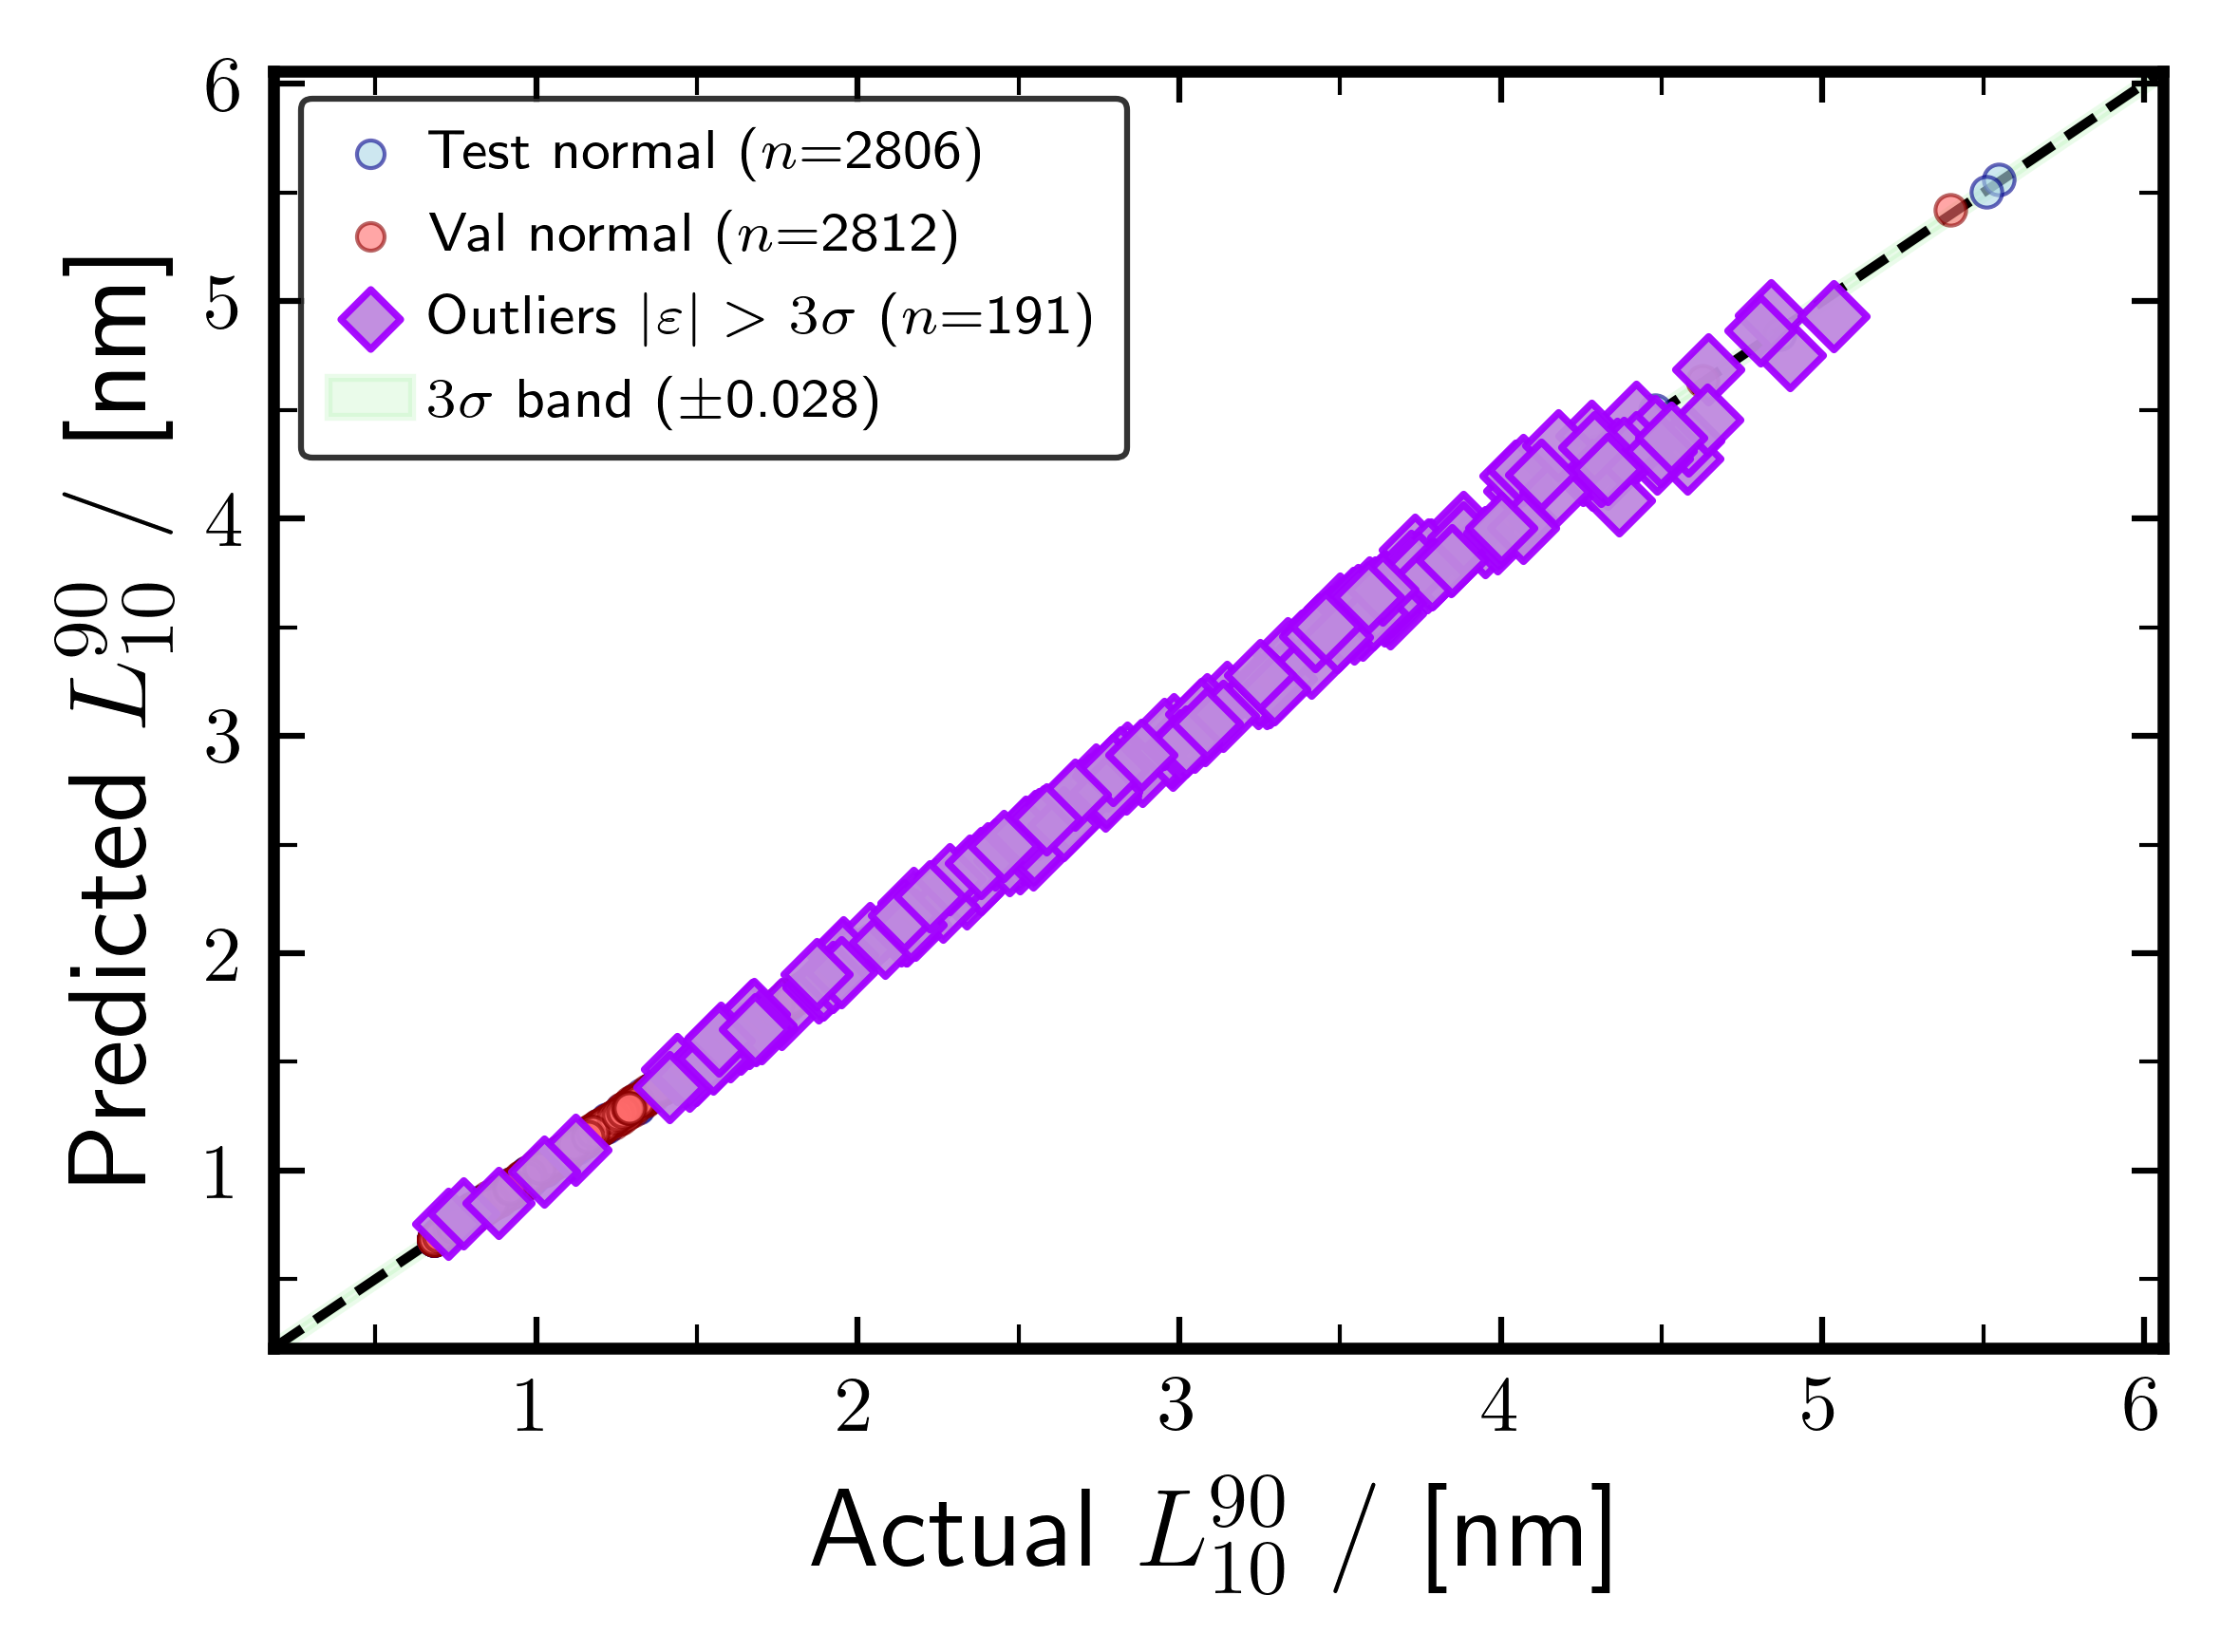

Saved: RF_interfacial_thickness_outlier_parity


In [10]:
# Outlier flagging: test + val samples where |residual| > 3 * global std

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3\u03c3): \u00b1{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_outliers.csv"), index=False)
print(f"Saved: RF_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=35, facecolors="#BF89DF", edgecolors="#A200FF",
        linewidths=0.9, marker='D', zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_outlier_parity")

In [11]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=N_JOBS)
cv_rmse_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=N_JOBS)
cv_mae_scores  = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
cv_mape_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=N_JOBS)

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:    {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE:  {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:   {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE:  {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.99912297 0.99884366 0.98719931 0.99856155 0.99822545]
Mean CV R²:    0.996391 (+/- 0.009211)

Cross-Validation RMSE Scores: [0.01879667 0.0226792  0.07854293 0.02694167 0.02952782]
Mean CV RMSE:  0.035298 (+/- 0.043861)

Cross-Validation MAE Scores:  [0.0082212  0.01192145 0.01397511 0.01192162 0.01180145]
Mean CV MAE:   0.011568 (+/- 0.003720)

Cross-Validation MAPE Scores: [0.5687602  0.80910581 0.73795358 0.7871947  0.69673054]
Mean CV MAPE:  0.7199% (+/- 0.1702%)


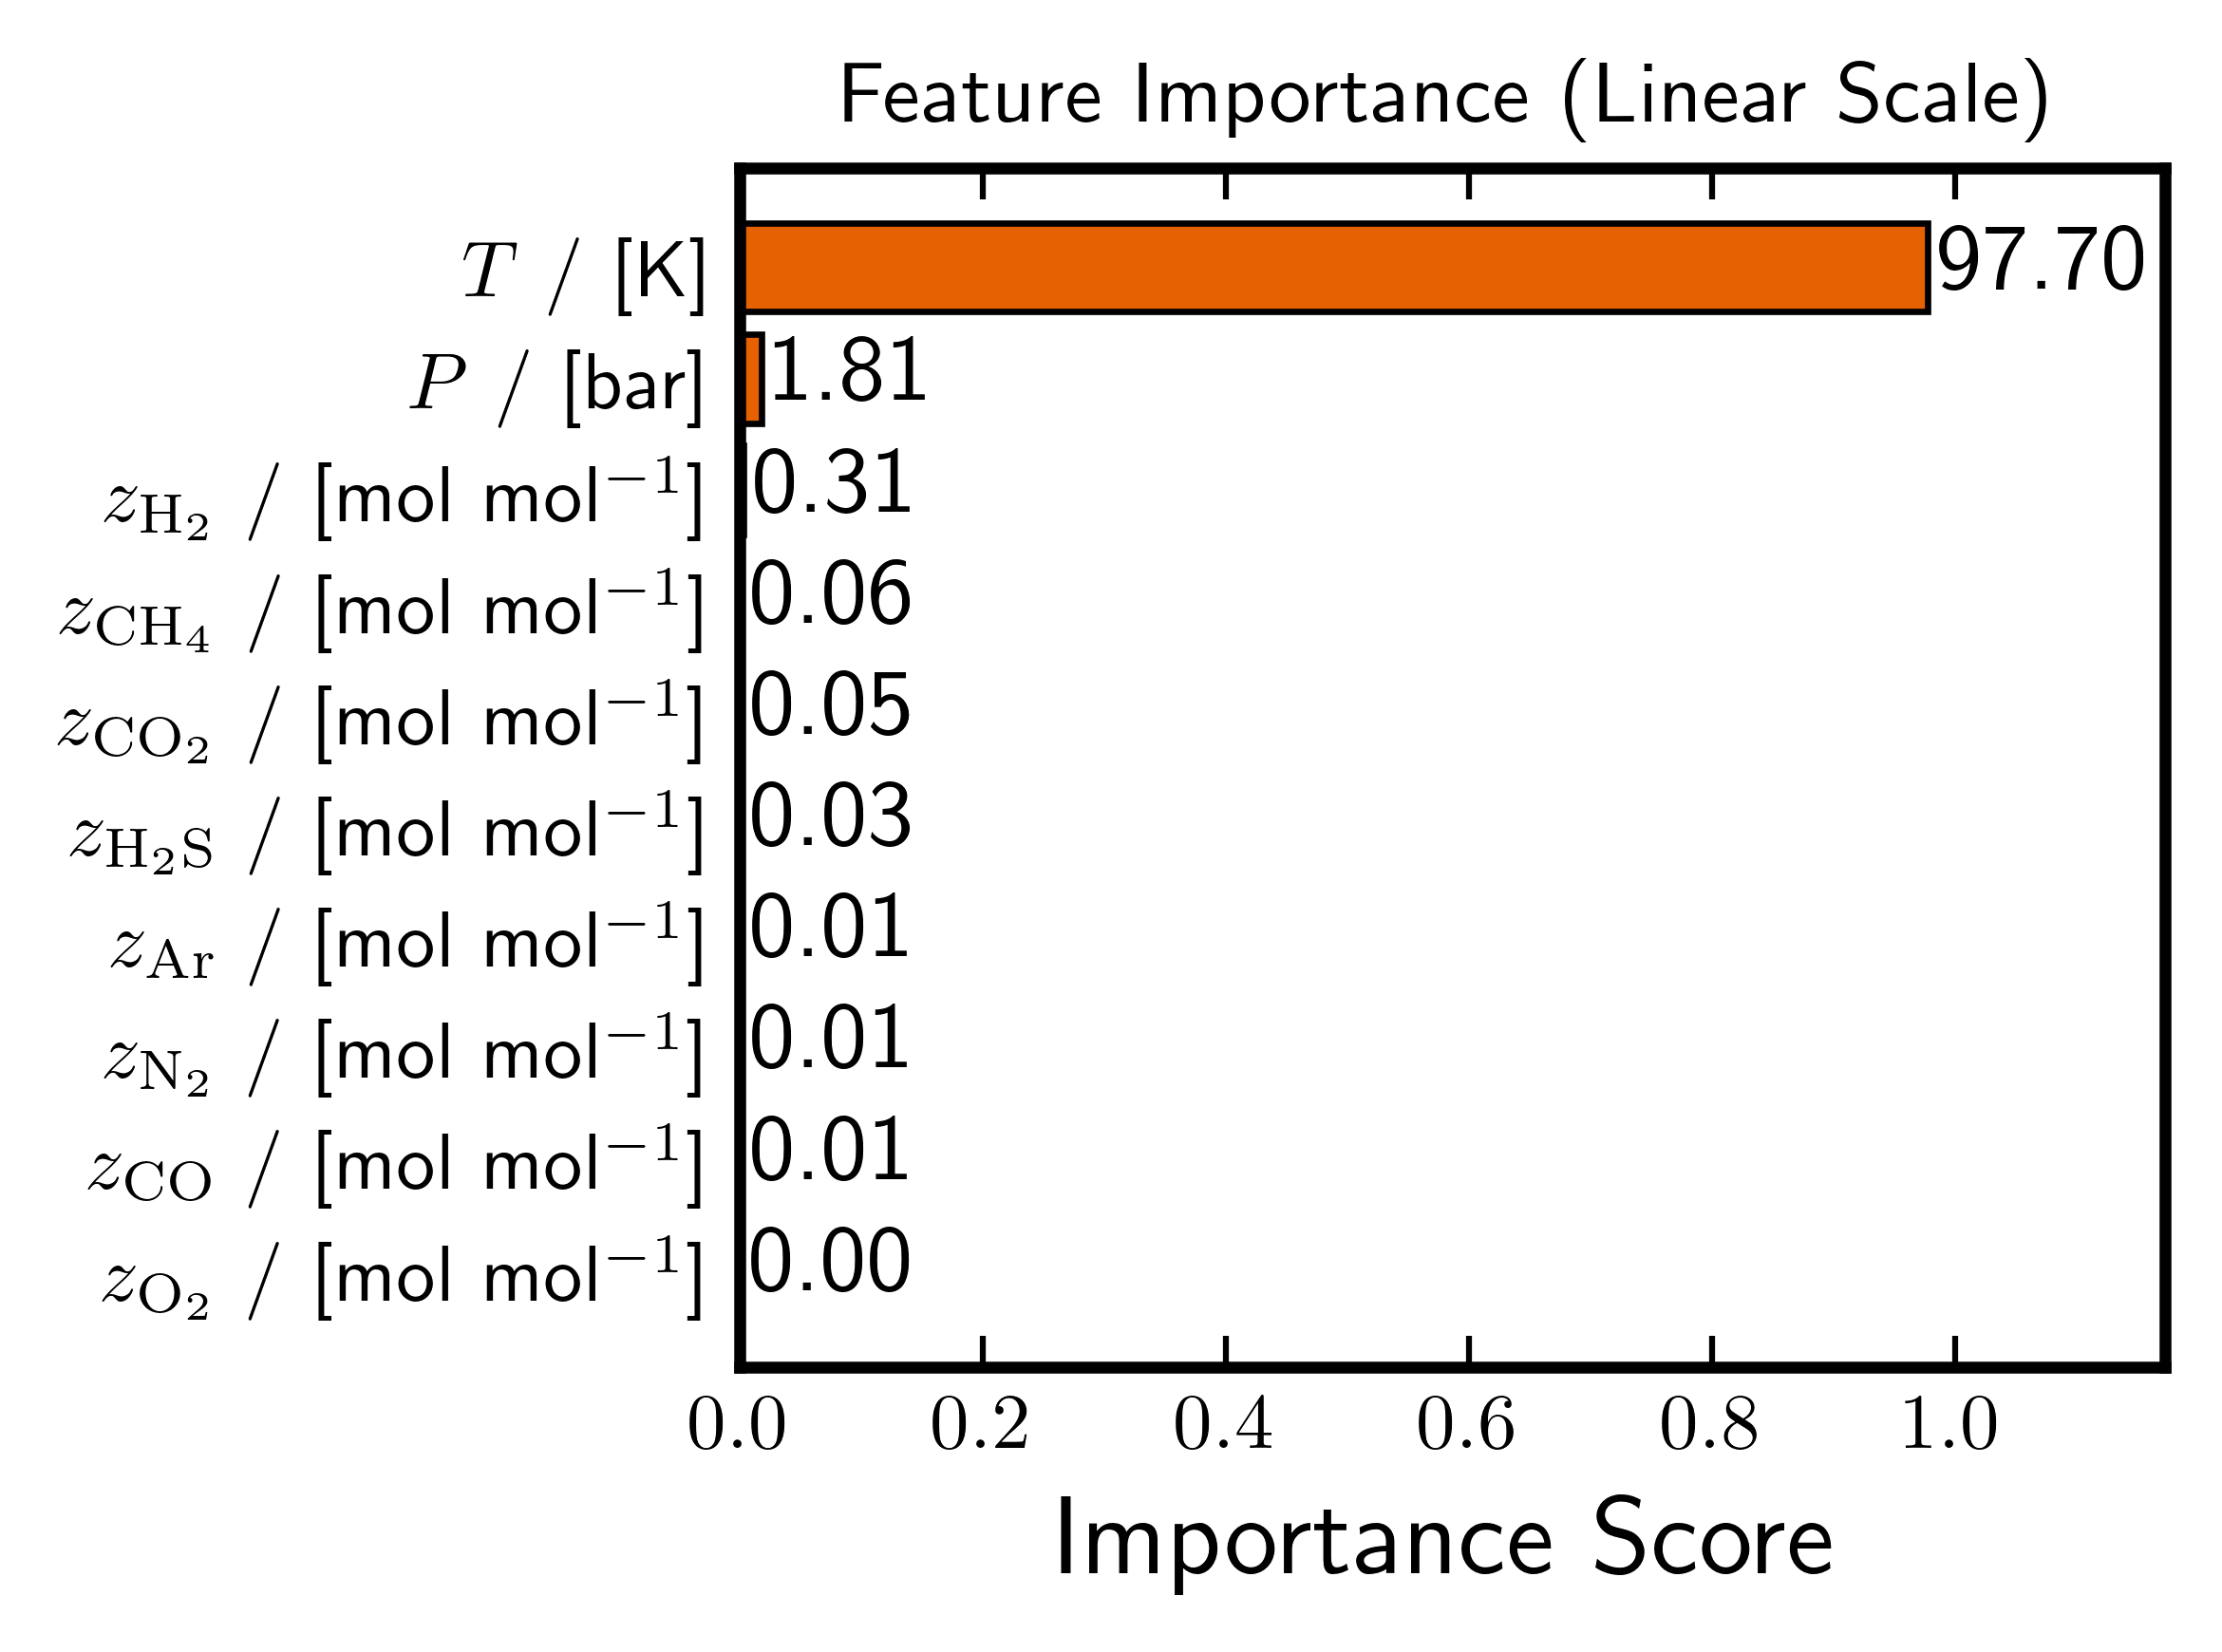

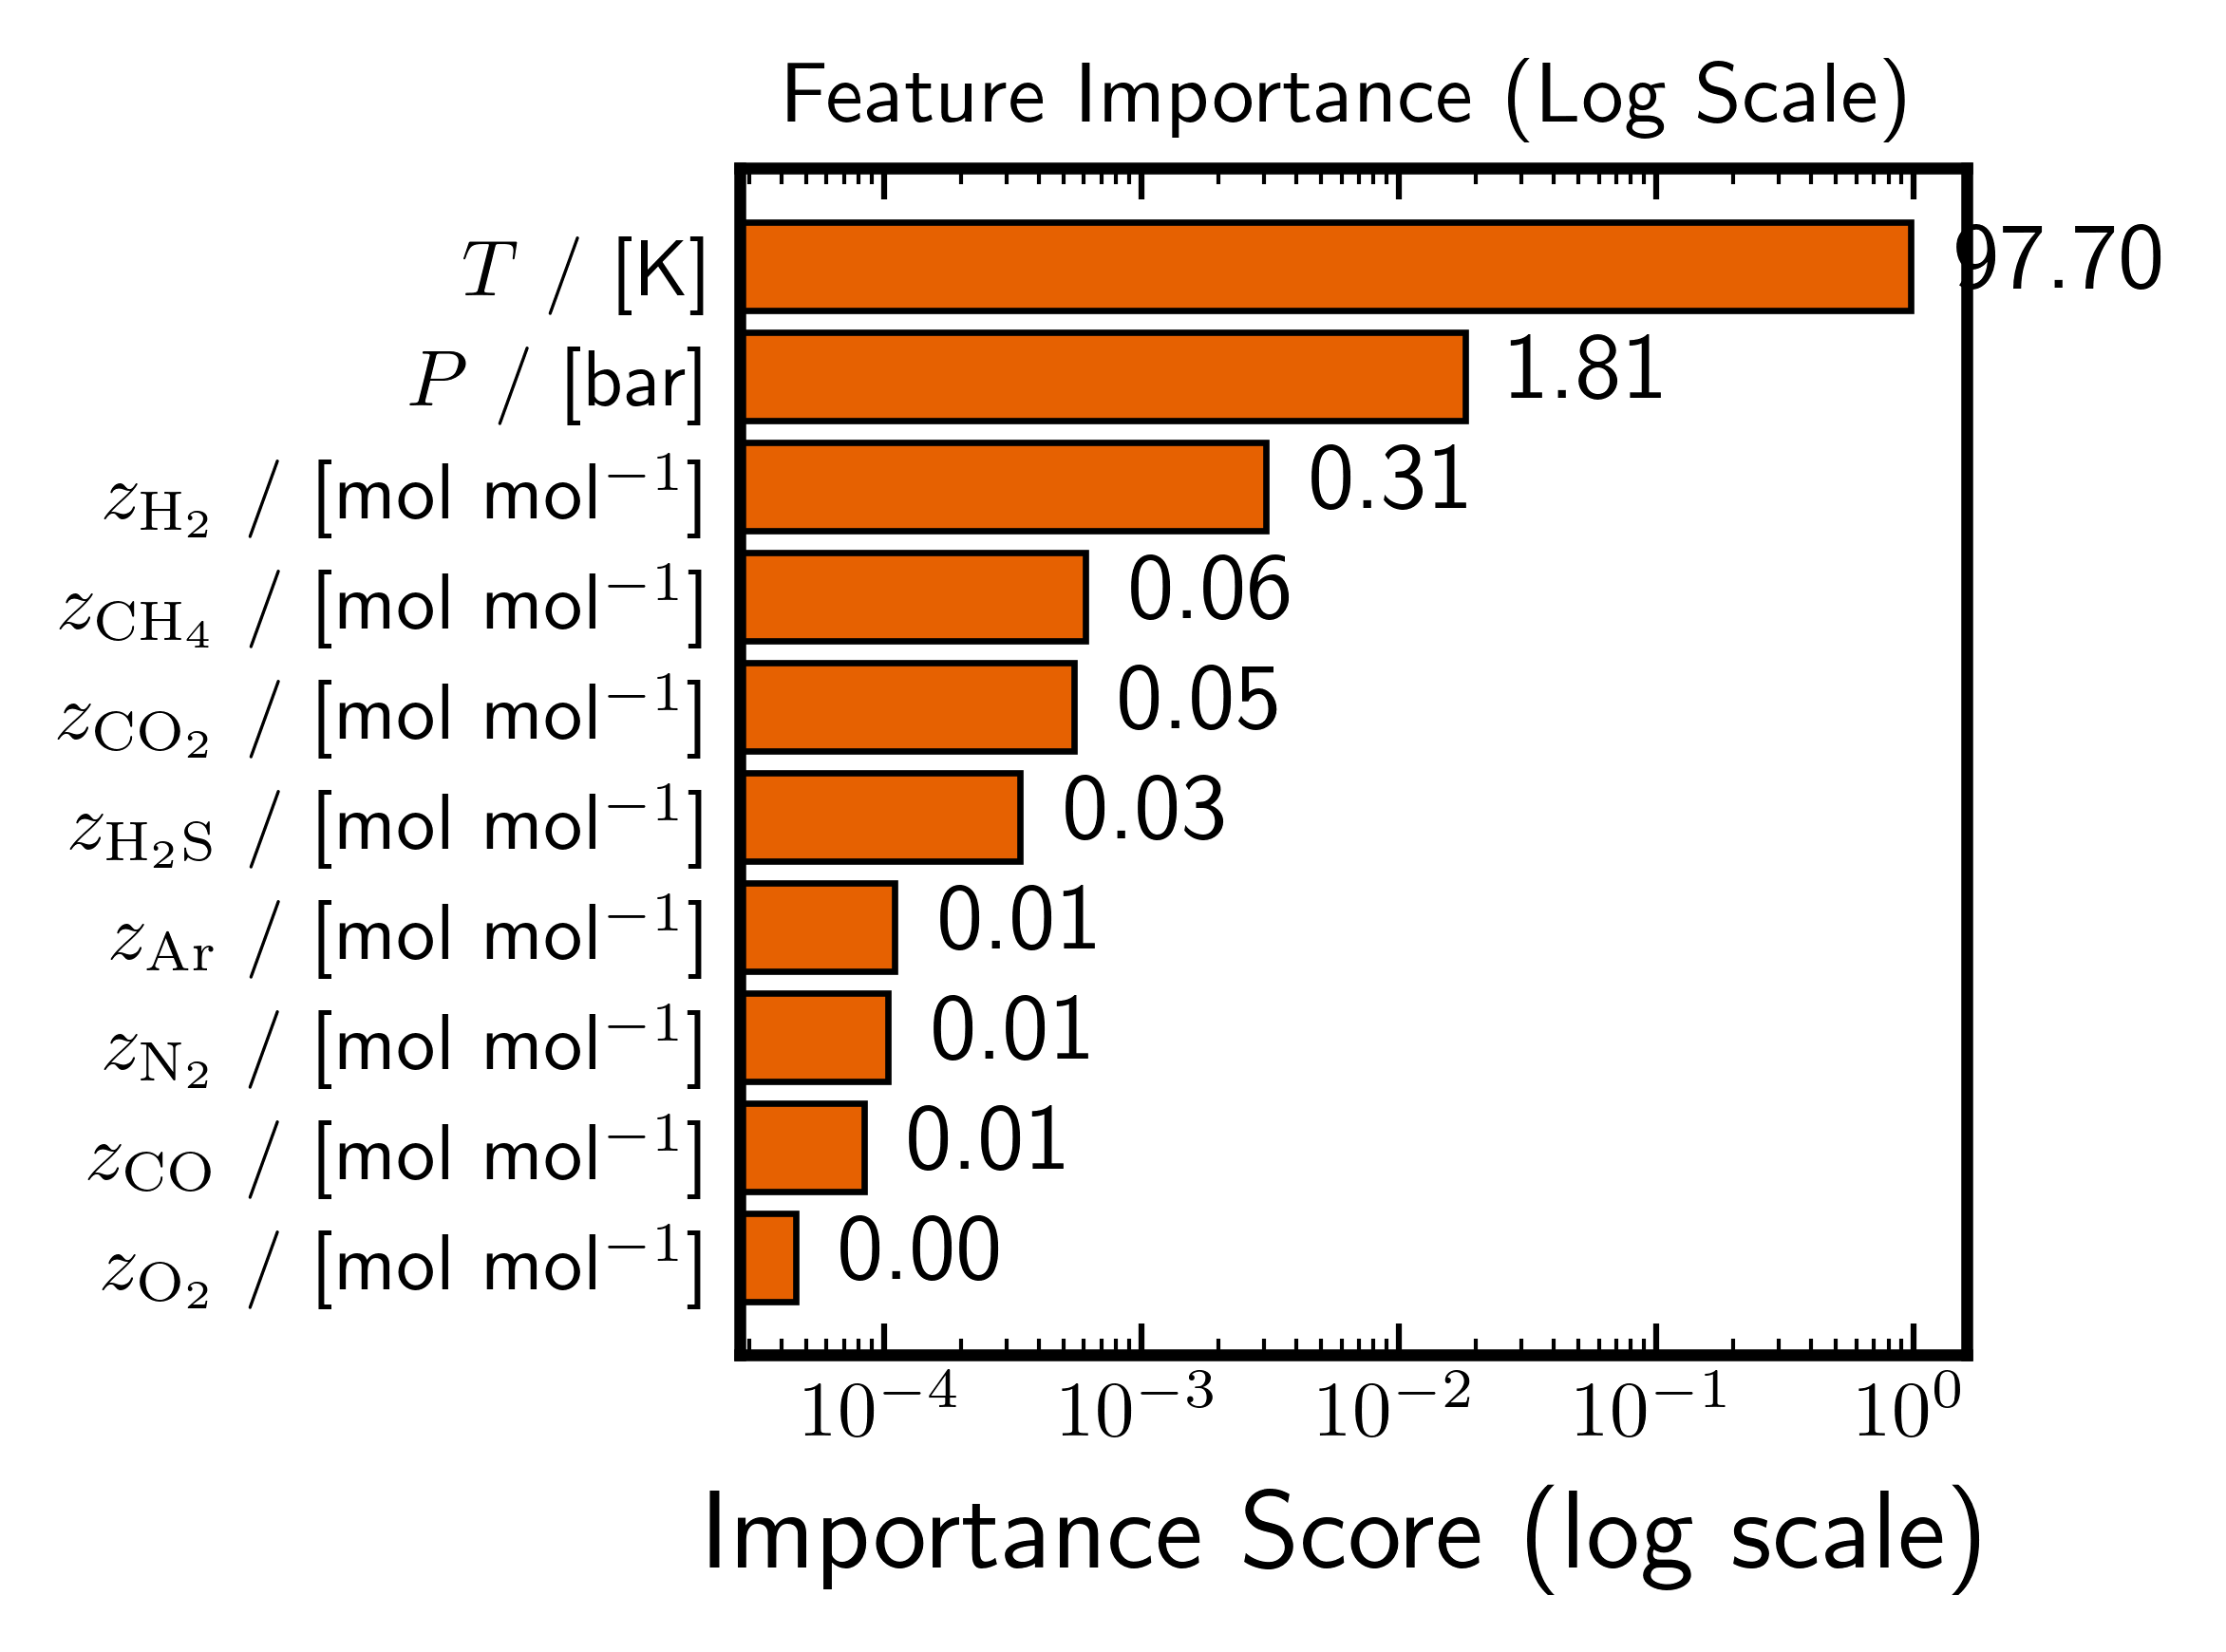

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Log Scale)'}, xlabel='Importance Score (log scale)'>)

In [12]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="interfacial_thickness",
    feature_importances=rf_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color=post.colors["hist_color"], save_path="RF_interfacial_thickness_feature_importance_linear", folder=OUTPUT_FOLDER)
# Plot feature importance (Log Scale)
post.plot_feature_importance(scale="log", color=post.colors["hist_color"], save_path="RF_interfacial_thickness_feature_importance_log", folder=OUTPUT_FOLDER)

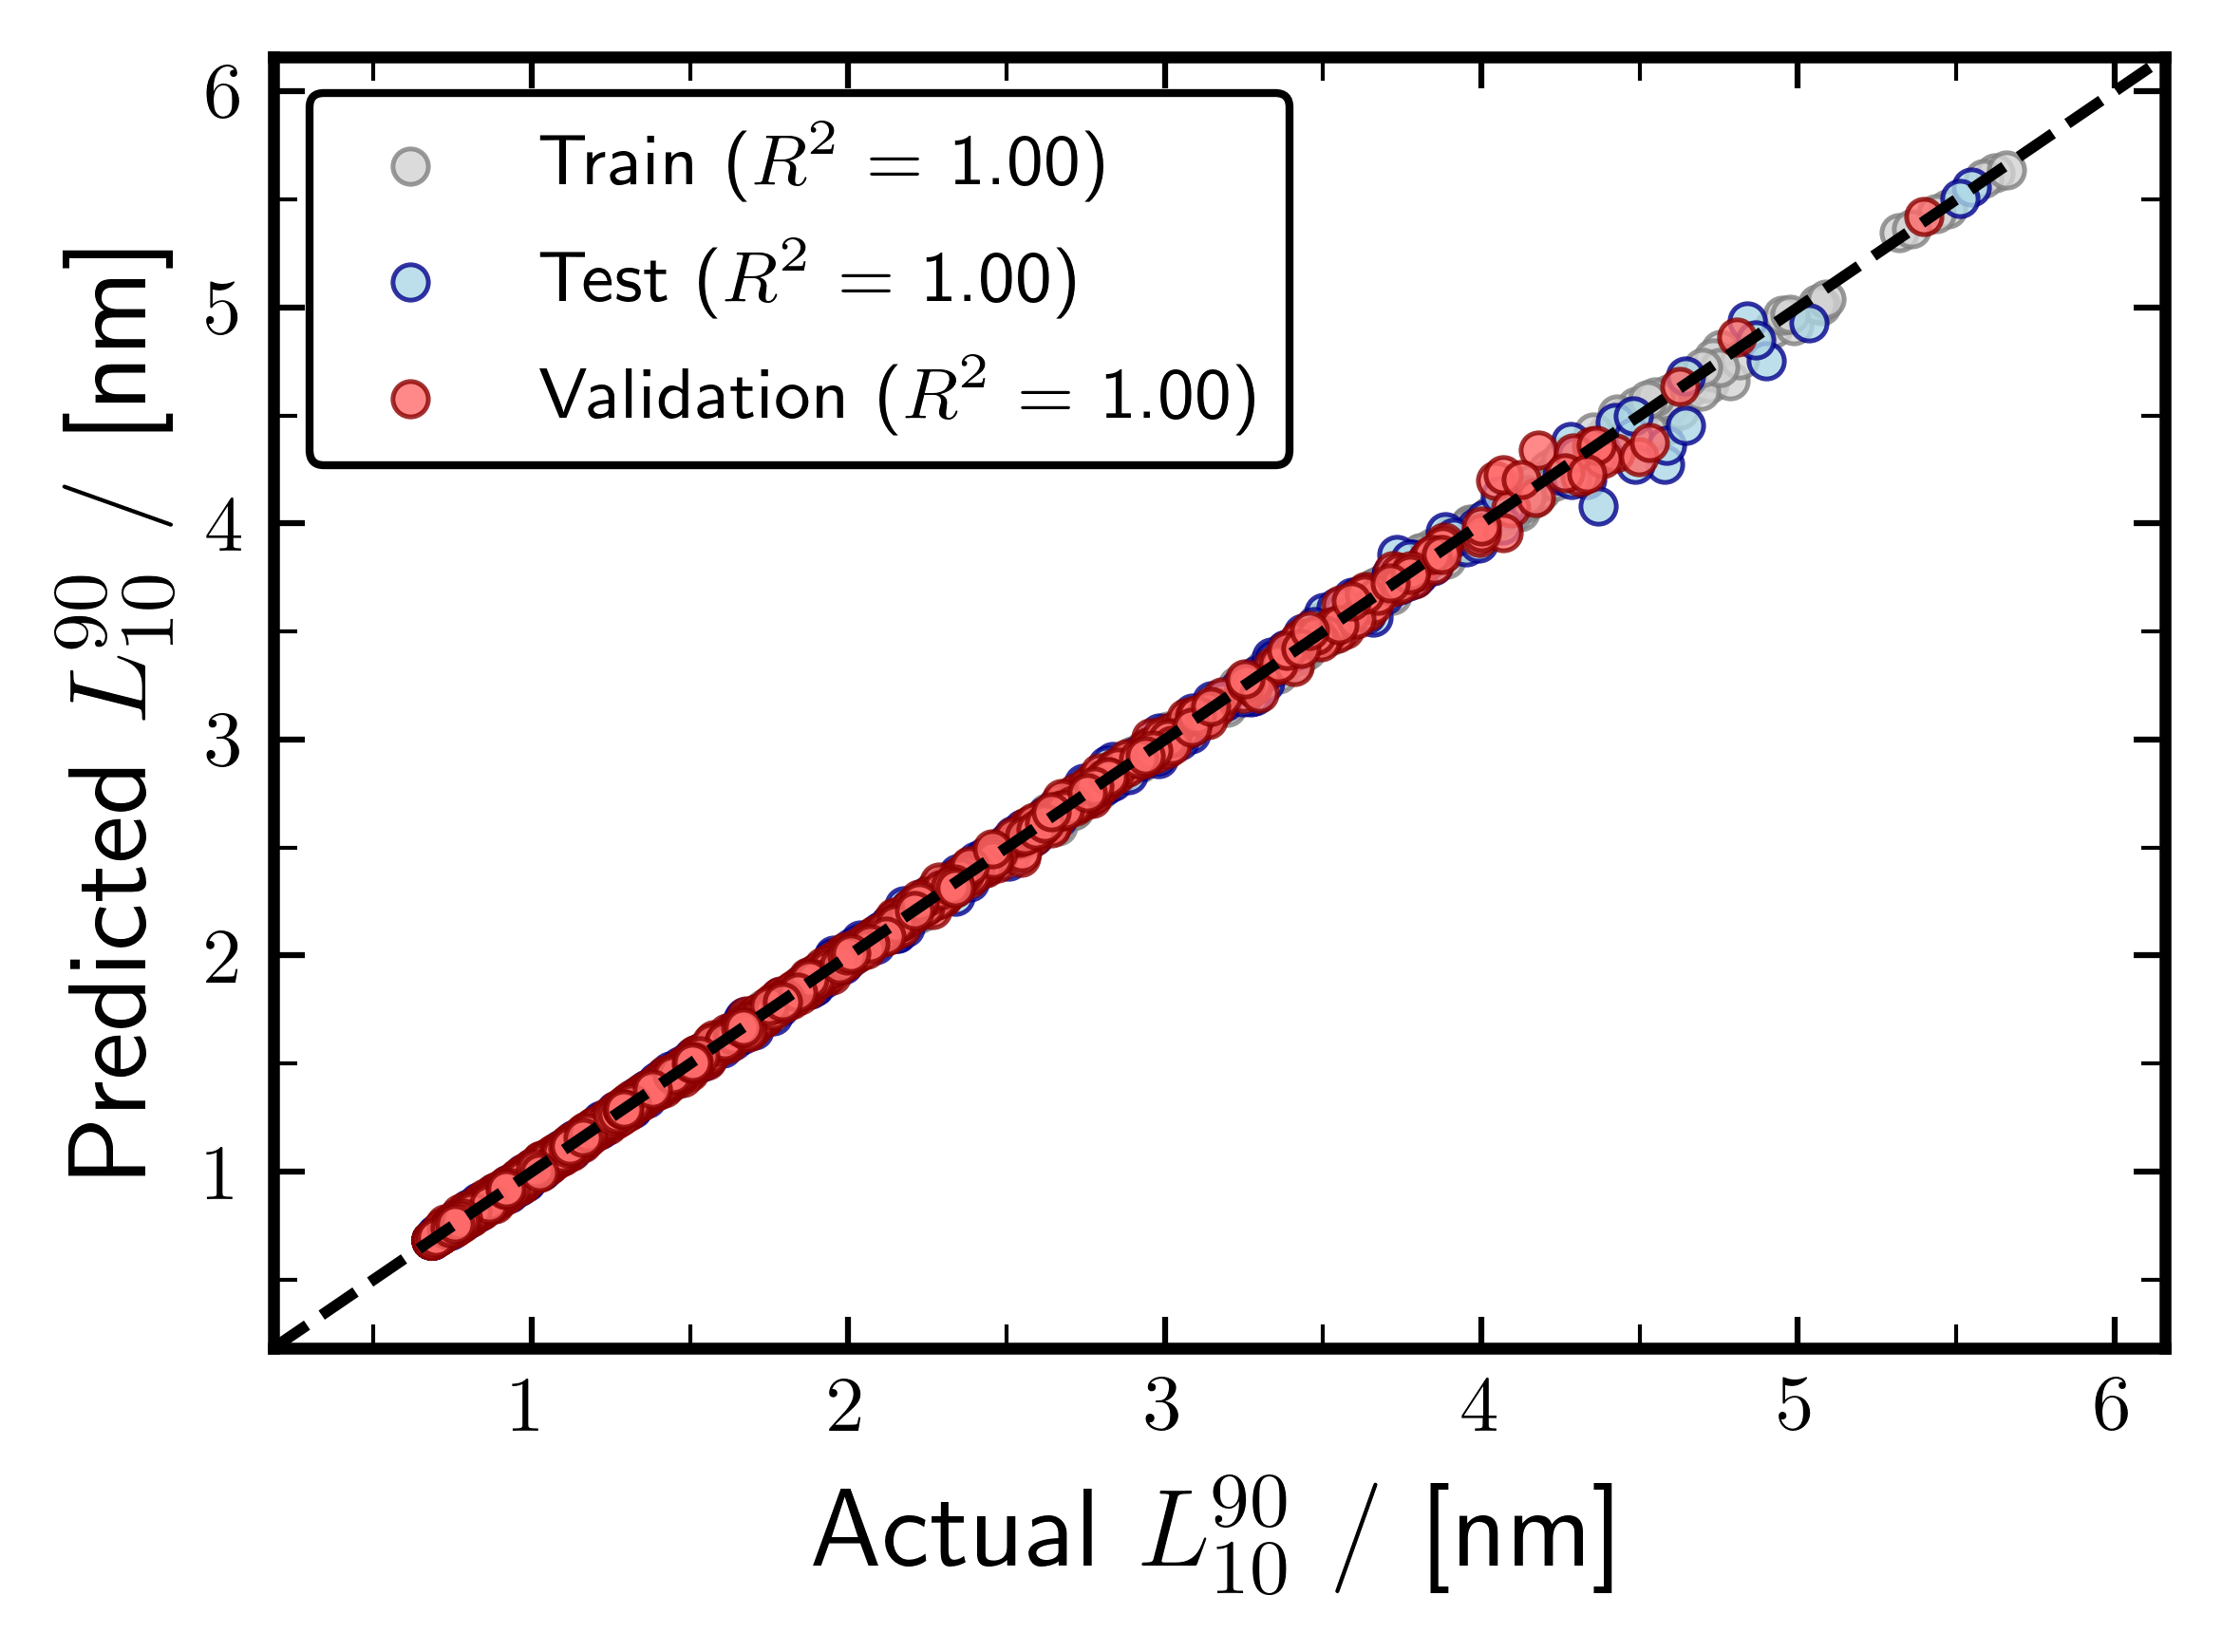

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $L^{90}_{10}$ / [nm]', ylabel='Predicted $L^{90}_{10}$ / [nm]'>)

In [13]:
# Parity plot
post.plot_parity(model_name="Random Forest", save_path="RF_interfacial_thickness_parity_plot", folder=OUTPUT_FOLDER,
                #  cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                 )

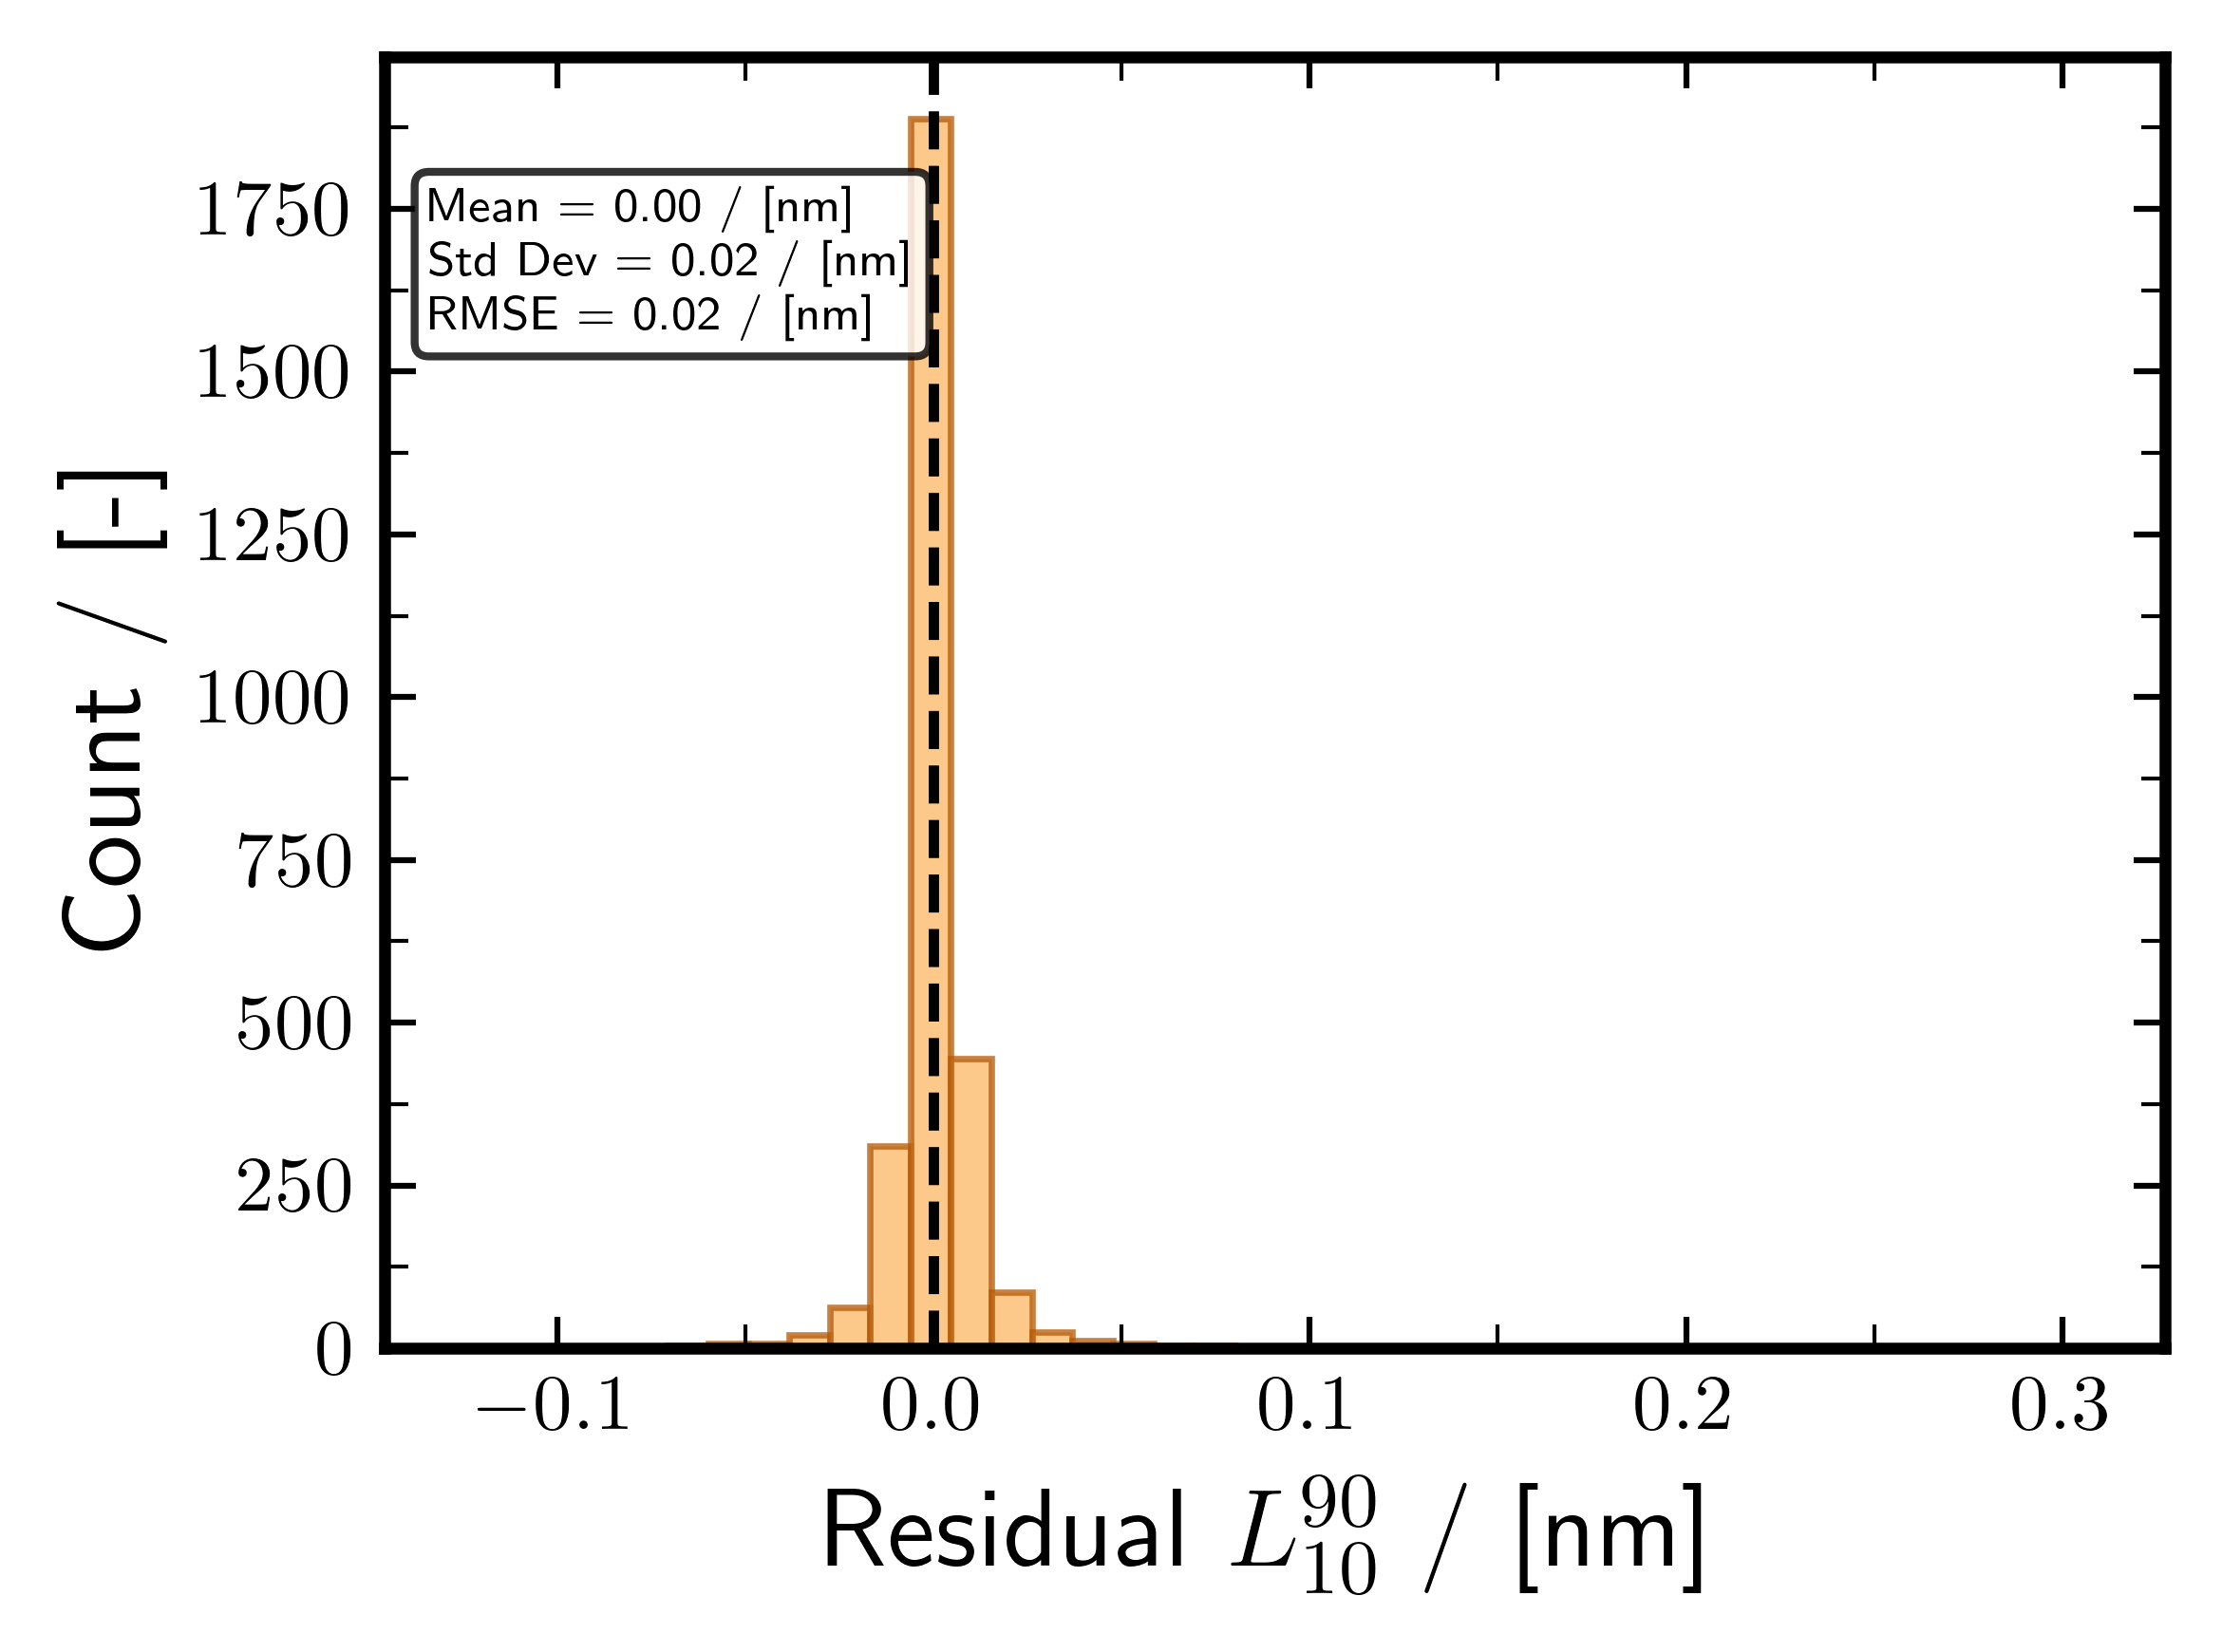

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $L^{90}_{10}$ / [nm]', ylabel='Count / [-]'>)

In [14]:
# Residual distribution
post.plot_residual_distribution(save_path="RF_interfacial_thickness_residual_distribution", folder=OUTPUT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

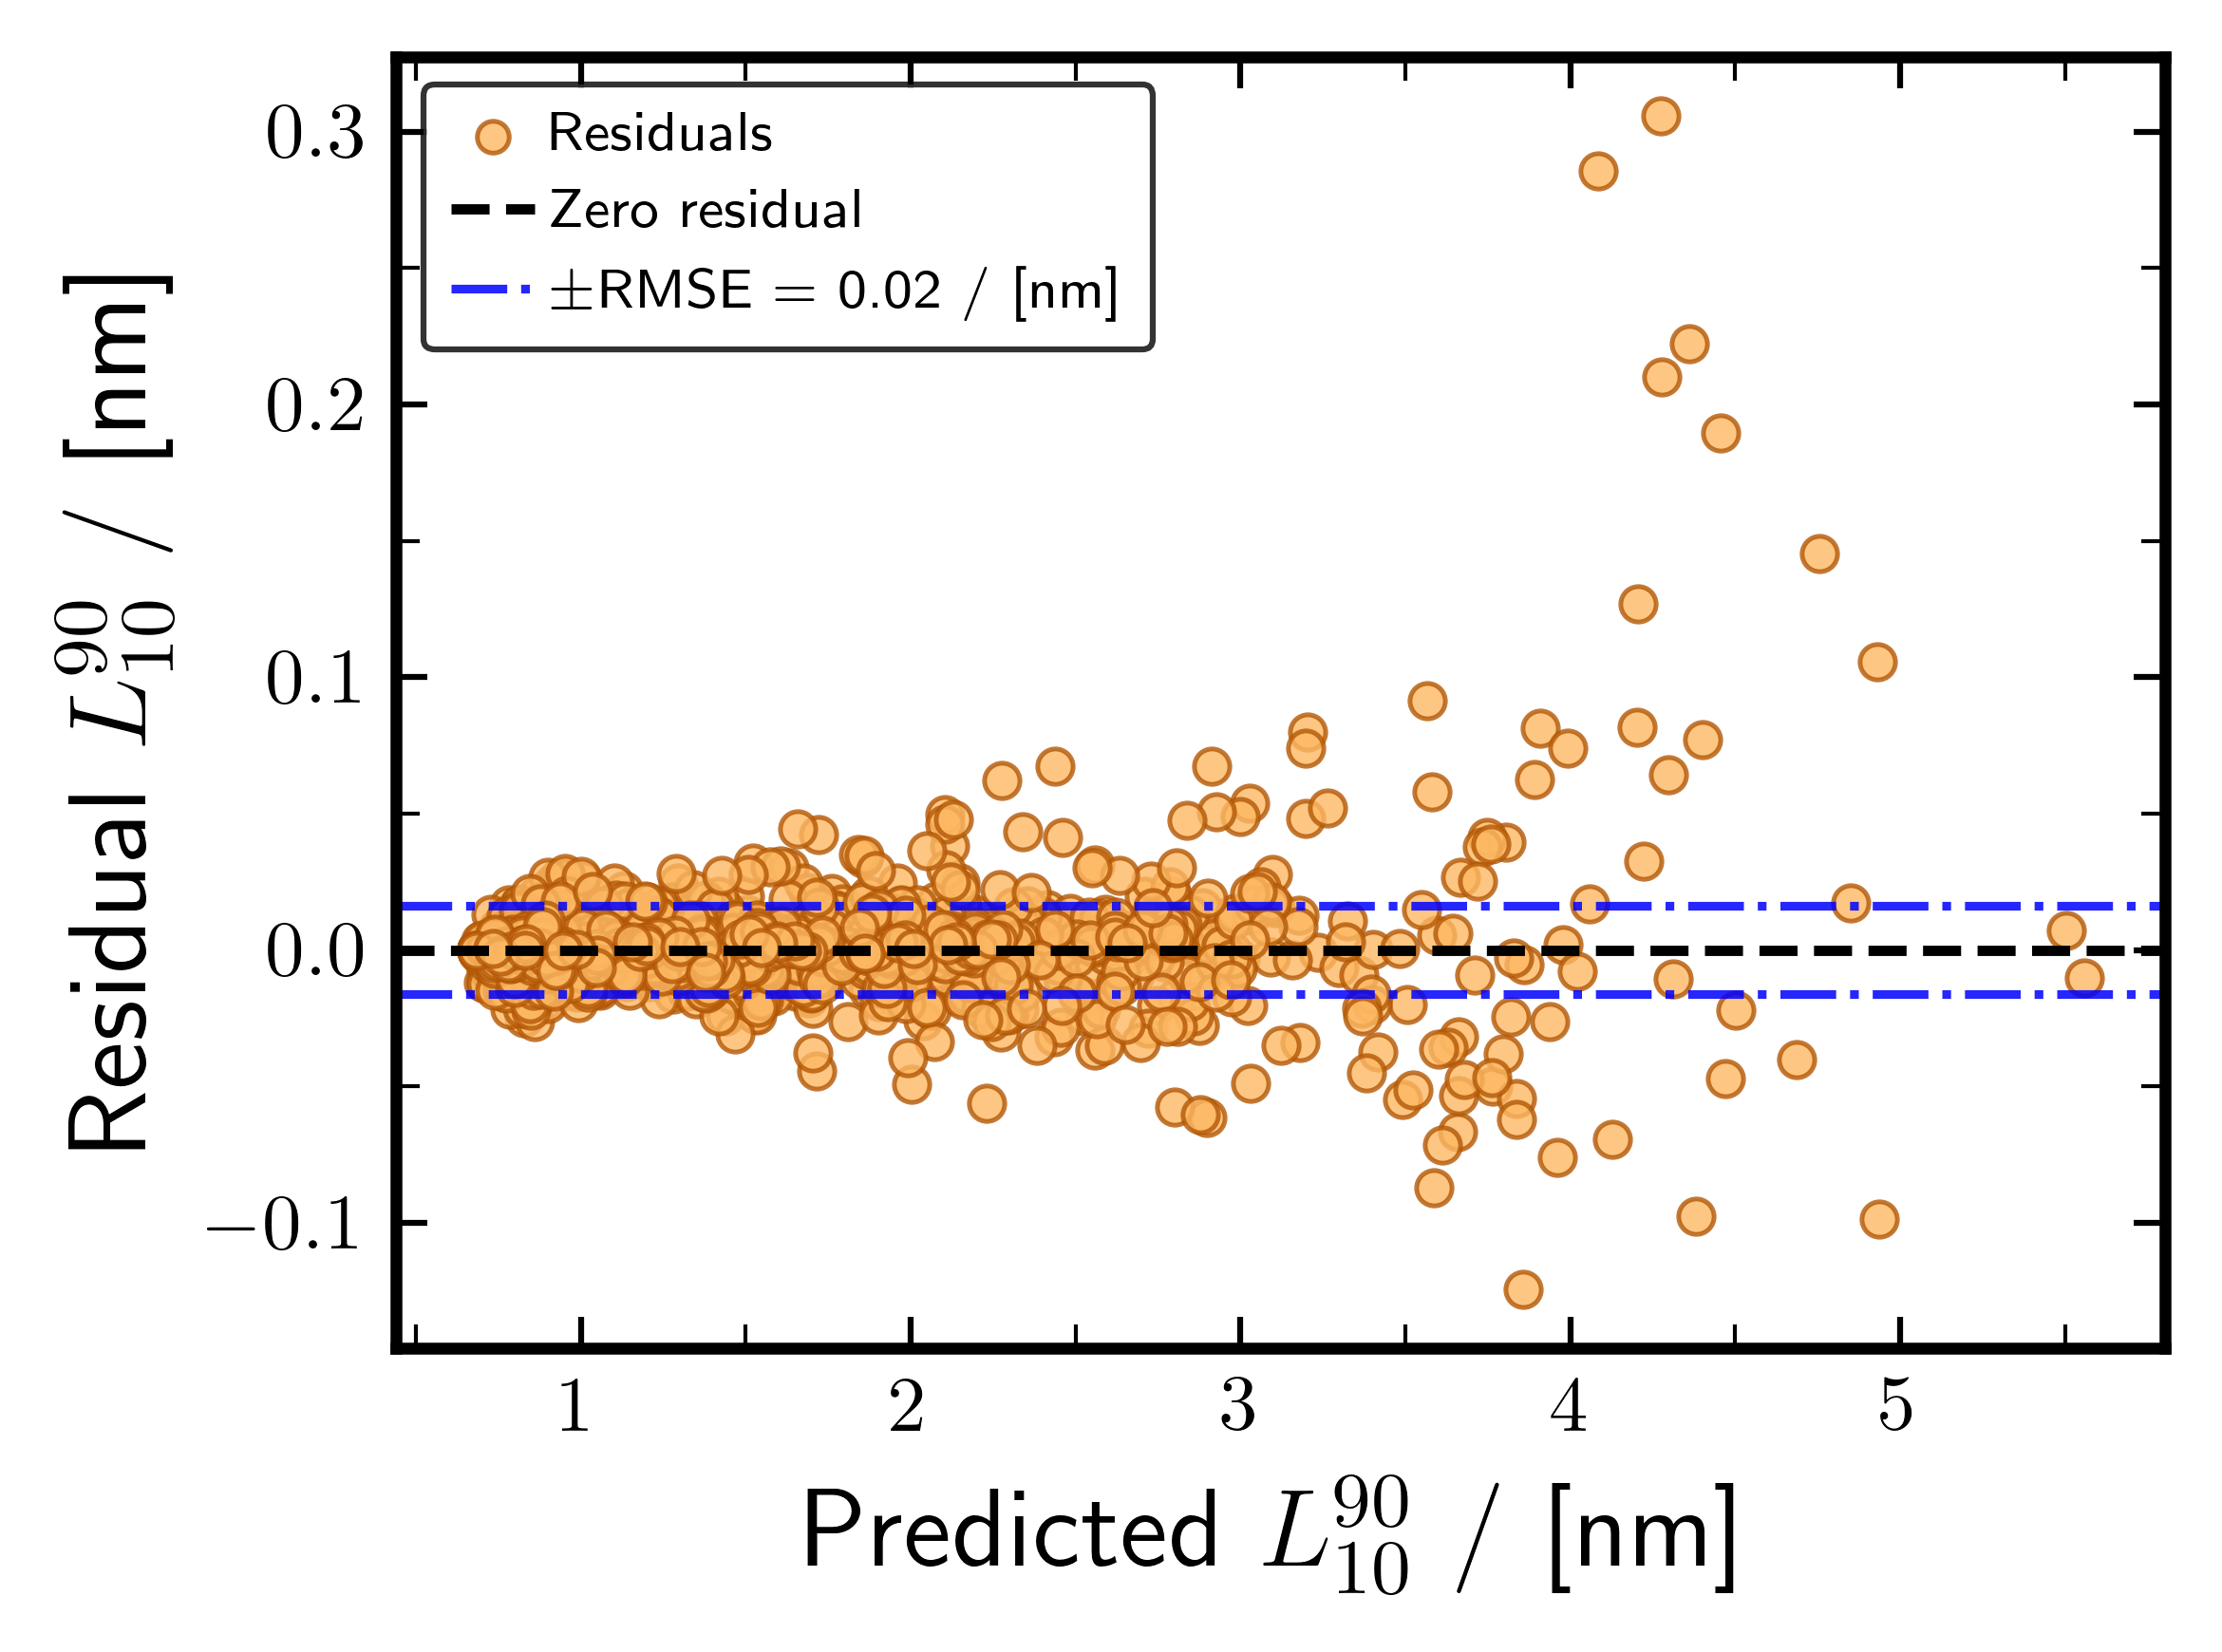

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $L^{90}_{10}$ / [nm]', ylabel='Residual $L^{90}_{10}$ / [nm]'>)

In [15]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="RF_interfacial_thickness_residual_vs_predicted", folder=OUTPUT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

In [16]:
post.print_summary()

# Collect all metrics
metrics["oob_score"]       = float(rf_model.oob_score_)
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["model"]           = "RandomForest"
metrics["n_estimators"]    = rf_model.n_estimators
metrics["max_depth"]       = rf_model.max_depth
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - INTERFACIAL_THICKNESS
Samples:        2904
R² Score:       0.999450
RMSE:           0.016157
MAE:            0.006787
Mean Residual:  0.000612
Std Residual:   0.016146

FEATURE IMPORTANCES:
------------------------------------------------------------
  temperature               |  97.70% | ████████████████████████████████████████████████
  pressure                  |   1.81% | 
  z_hydrogen                |   0.31% | 
  z_methane                 |   0.06% | 
  z_carbon dioxide          |   0.05% | 
  z_hydrogen sulfide        |   0.03% | 
  z_argon                   |   0.01% | 
  z_nitrogen                |   0.01% | 
  z_carbon monoxide         |   0.01% | 
  z_oxygen                  |   0.00% | 

Metrics saved to: RF_THICKNESS_OUTPUTS/RF_interfacial_thickness_metrics.json


In [17]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.35 minutes
